## Charmonia Primordial Suppression in pPb Collision

## Load & Preprocess Datafiles

### Imports & Data Loading && Helpers

In [11]:
import sys
import os
from pathlib import Path

def setup_project_path():
    # Start at current notebook directory
    curr = Path().resolve()
    
    # Search upwards for the directory that CONTAINS 'primordial_code'
    for parent in [curr] + list(curr.parents):
        if (parent / "primordial_code").is_dir():
            if str(parent) not in sys.path:
                sys.path.insert(0, str(parent))
            return parent
    return None

project = setup_project_path()

if project:
    print(f"✅ Success! Project root found at: {project}")
    from primordial_code.primordial_module import (
        ReaderConfig, Style, Y_WINDOW_BACKWARD, Y_WINDOW_CENTRAL,
        Y_WINDOW_FORWARD, build_ensemble, make_bins_from_width
    )
    from primordial_code.glauber_bridge import GlauberBridgeConfig, generate_primordial_glauber_maps
    print("✅ Modules imported successfully.")
else:
    print("❌ Could not find 'primordial_code' in any parent directories.")
    print(f"I searched from: {Path().resolve()}")

✅ Success! Project root found at: /home/sawin/Desktop/Charmonia/charmonia_combined_analysis
✅ Modules imported successfully.


In [12]:
# ONLY insert the root project directory
if str(project) not in sys.path:
    sys.path.insert(0, str(project))

# Now these will work because Python sees the 'primordial_code' folder from the root
from primordial_code.primordial_module import (
    ReaderConfig,
    Style,
    Y_WINDOW_BACKWARD,
    Y_WINDOW_CENTRAL,
    Y_WINDOW_FORWARD,
    build_ensemble,
    make_bins_from_width,
)

from primordial_code.glauber_bridge import (
    GlauberBridgeConfig, 
    generate_primordial_glauber_maps
)

In [15]:
## ---------- I/O + switches ----------
outdir = project / "primordial_output"
outdir.mkdir(exist_ok=True, parents=True)

SAVE_PDF = True
SAVE_CSV = True
DPI = 150
ALPHA_BAND = 0.22

# ---------- choose energy ----------
ENERGY = "8.16"  # "8.16" or "5.02"
SQRTS_GeV = 8160.0 if ENERGY == "8.16" else 5020.0
MODELS = ("Pert", "NPWLC")

In [17]:
from typing import Dict, Iterable, List, Tuple
from dataclasses import dataclass


@dataclass
class PrimordialCombo:
    energy: str
    model: str
    form: str
    ens: object
    runs: Dict[str, object]


STATES = ["jpsi_1S", "chicJ_1P", "psi_2S"]
STATE_LABELS = {
    "jpsi_1S": r"$J/\psi(1S)$",
    "chicJ_1P": r"$\chi_c(1P)$",
    "psi_2S": r"$\psi(2S)$",
}
MODEL_COLORS = {"Pert": "tab:blue", "NPWLC": "tab:red"}
MODEL_LS = {"Pert": "-", "NPWLC": "--"}
MODELS = ("Pert", "NPWLC")

Y_WINDOWS = {
    "forward": Y_WINDOW_FORWARD,
    "central": Y_WINDOW_CENTRAL,
    "backward": Y_WINDOW_BACKWARD,
}

TAUFORM_BINDING = {
    "jpsi_1S": (0.31, 0.62),
    "chicJ_1P": (1.20, 2.40),
    "psi_2S": (4.50, 9.00),
}
TAUFORM_OLD = {
    "jpsi_1S": (1.0, 1.25),
    "chicJ_1P": (1.5, 1.875),
    "psi_2S": (2.5, 3.125),
}
TAUFORM_RADIUS = {
    "jpsi_1S": (1.58, 3.16),
    "chicJ_1P": (2.41, 4.82),
    "psi_2S": (3.30, 6.59),
}


def _paths_for_form(energy: str, form: str) -> Dict[str, Path]:
    # Base prefixes must end with ".../output" so build_ensemble can append "_tau1/_tau2".
    base = PROJECT / "input/primordial/LHC"
    if energy == "8.16":
        if form == "new":
            return {
                "Pert": base / "pPb8TeV/pPb8TeV_Pert_diffT0/output_8pPb_diffT0_new/output",
                "NPWLC": base / "pPb8TeV/pPb8TeV_NPWLC_diffT0/output_8pPb_diffT0_new/output",
            }
        if form == "old":
            return {
                "Pert": base / "pPb8TeV/pPb8TeV_Pert_diffT0/output_8pPb_diffT0_old/output",
                "NPWLC": base / "pPb8TeV/pPb8TeV_NPWLC_diffT0/output_8pPb_diffT0_old/output",
            }
        if form == "radius":
            return {
                "Pert": base / "pPb8TeV/pPb8TeV_Pert_diffT0/output_8pPb_diffT0_radius/output",
                "NPWLC": base / "pPb8TeV/pPb8TeV_NPWLC_diffT0/output_8pPb_diffT0_radius/output",
            }
    if energy == "5.02":
        if form == "new":
            return {
                "Pert": base / "pPb5TeV/pPb5TeV_Pert_diffT0/output_5pPb_diffT0_new/output",
                "NPWLC": base / "pPb5TeV/pPb5TeV_NPWLC_diffT0/output_5pPb_diffT0_new/output",
            }
        if form == "old":
            return {
                "Pert": base / "pPb5TeV/pPb5TeV_Pert_diffT0/output_5pPb_diffT0_old/output",
                "NPWLC": base / "pPb5TeV/pPb5TeV_NPWLC_diffT0/output_5pPb_diffT0_old/output",
            }
        if form == "radius":
            return {
                "Pert": base / "pPb5TeV/pPb5TeV_Pert_diffT0/output_5pPb_diffT0_radius/output",
                "NPWLC": base / "pPb5TeV/pPb5TeV_NPWLC_diffT0/output_5pPb_diffT0_radius/output",
            }
    raise ValueError(f"Unsupported energy/form: {energy}/{form}")


def _tauform_for_form(form: str) -> Dict[str, Tuple[float, float]]:
    if form == "new":
        return TAUFORM_BINDING
    if form == "old":
        return TAUFORM_OLD
    if form == "radius":
        return TAUFORM_RADIUS
    raise ValueError(form)


def _iter_ywins(y_wins: Dict[str, Tuple[float, float]]) -> Iterable[Tuple[str, float, float]]:
    for key, win in y_wins.items():
        y0, y1 = tuple(win)
        yield key, y0, y1


def _maps_from_runs(runs_dict):
    return next(iter(runs_dict.values())).centrality


def _centrality_percent(maps, bvals):
    bvals = np.asarray(bvals, float)
    c = maps.b_to_c(bvals).astype(float)
    if np.isfinite(c).any():
        cmax = float(np.nanmax(c))
        if cmax <= 1.5:
            c *= 100.0
        elif cmax > 150.0:
            c /= (cmax / 100.0)
    good = np.isfinite(c)
    span = (np.nanmax(c[good]) - np.nanmin(c[good])) if good.any() else 0.0
    if (not good.all()) or (span < 5.0):
        bu = np.unique(bvals)
        n = len(bu)
        centers = (np.arange(n) + 0.5) * (100.0 / max(1, n))
        order = np.argsort(bu)
        c = np.interp(bvals, bu[order], centers[order])
    return c


def _aggregate_class(df_center_b, df_band_b, maps, cent_lo, cent_hi, states, xname, weight="nbin"):
    bs = np.sort(df_center_b["b"].unique())
    cents = _centrality_percent(maps, bs)
    sel_b = bs[(cents >= cent_lo) & (cents < cent_hi)]
    if sel_b.size == 0:
        return None, None
    dc = df_center_b[df_center_b["b"].isin(sel_b)].copy()
    db = df_band_b[df_band_b["b"].isin(sel_b)].copy() if df_band_b is not None else None
    if weight == "nbin":
        wmap = dict(zip(sel_b, maps.b_to_nbin(sel_b)))
    else:
        wmap = {b: 1.0 for b in sel_b}
    for b in list(wmap):
        w = wmap[b]
        if (not np.isfinite(w)) or (w <= 0.0):
            wmap[b] = 1.0
    rows = []
    for xv, chunk in dc.groupby(xname, sort=True):
        ws = np.array([wmap[b] for b in chunk["b"]], float)
        denom = ws.sum()
        ws = ws / denom if np.isfinite(denom) and denom > 0 else np.ones_like(ws) / max(1, len(ws))
        row = {xname: float(xv)}
        for s in states:
            row[s] = float(np.sum(ws * chunk[s].to_numpy(float)))
        rows.append(row)
    dfc = pd.DataFrame(rows).sort_values(xname).reset_index(drop=True)
    dfb = None
    if db is not None:
        rowsb = []
        for xv, ch in db.groupby(xname, sort=True):
            rb = {xname: float(xv)}
            for s in states:
                lo = ch.get(f"{s}_lo", pd.Series(dtype=float))
                hi = ch.get(f"{s}_hi", pd.Series(dtype=float))
                if not lo.empty and not hi.empty:
                    rb[f"{s}_lo"] = float(np.nanmin(lo.to_numpy(float)))
                    rb[f"{s}_hi"] = float(np.nanmax(hi.to_numpy(float)))
            rowsb.append(rb)
        dfb = pd.DataFrame(rowsb).sort_values(xname).reset_index(drop=True)
    return dfc, dfb


def _centrality_slice_weights(maps, df_center_b, cent_classes, scheme="nbin"):
    bs = np.sort(df_center_b["b"].unique())
    cents = _centrality_percent(maps, bs)
    if scheme == "nbin":
        w_b = maps.b_to_nbin(bs)
        w_b = np.where((w_b > 0) & np.isfinite(w_b), w_b, 1.0)
    else:
        w_b = np.ones_like(bs, float)
    w_slices = []
    for lo, hi in cent_classes:
        m = (cents >= lo) & (cents < hi)
        w_slices.append(np.sum(w_b[m]))
    w_slices = np.asarray(w_slices, float)
    if not np.any(w_slices > 0):
        w_slices = np.ones_like(w_slices)
    return w_slices / w_slices.sum()


def step_from_centers(x_cent, vals):
    x_cent = np.asarray(x_cent, float)
    vals = np.asarray(vals, float)
    n = x_cent.size
    if n == 0:
        return np.array([]), np.array([])
    if n == 1:
        x_edges = np.array([x_cent[0] - 0.5, x_cent[0] + 0.5], float)
    else:
        dx = np.diff(x_cent)
        if np.allclose(dx, dx[0]):
            x_edges = np.concatenate(([x_cent[0] - 0.5 * dx[0]], x_cent + 0.5 * dx[0]))
        else:
            x_edges = np.empty(n + 1, float)
            x_edges[1:-1] = 0.5 * (x_cent[:-1] + x_cent[1:])
            x_edges[0] = x_cent[0] - 0.5 * (x_cent[1] - x_cent[0])
            x_edges[-1] = x_cent[-1] + 0.5 * (x_cent[-1] - x_cent[-2])
    return x_edges, np.concatenate([vals, vals[-1:]])


def _sorted_cent_tags(model_block):
    all_tags = set(model_block.keys())
    mb = [t for t in all_tags if "MB" in t]
    non_mb = [t for t in all_tags if "MB" not in t]
    non_mb = sorted(non_mb, key=lambda t: float(t.split("–")[0]))
    return non_mb + mb


def _validate_glauber_maps(groot: Path) -> None:
    required = ["bvscData.tsv", "nbinvsbData.tsv", "npartvsbData.tsv"]
    for nm in required:
        p = groot / nm
        if not p.exists():
            raise FileNotFoundError(f"Missing generated map file: {p}")
        arr = np.loadtxt(p, comments="#")
        if arr.ndim != 2 or arr.shape[1] < 2:
            raise RuntimeError(f"Bad map shape in {p}: {arr.shape}")
        if not np.all(np.isfinite(arr[:, :2])):
            raise RuntimeError(f"Non-finite values in {p}")
    bv = np.loadtxt(groot / "bvscData.tsv", comments="#")
    if np.any(np.diff(bv[:, 0]) < -1e-12):
        raise RuntimeError("b grid is not non-decreasing in bvscData.tsv")


def _load_primordial_combos(
    energy: str,
    form: str,
    glauber_root: Path,
    cfg: ReaderConfig,
) -> List[PrimordialCombo]:
    paths = _paths_for_form(energy, form)
    if form == "new":
        tags = ("lower_binding", "upper_binding")
    elif form == "old":
        tags = ("lower_old", "upper_old")
    elif form == "radius":
        tags = ("lower_radius", "upper_radius")
    else:
        raise ValueError(form)
    combos: List[PrimordialCombo] = []
    for model in MODELS:
        base = paths[model]
        try:
            ens, runs = build_ensemble(
                str(base),
                str(glauber_root),
                tags=tags,
                cfg=cfg,
                sqrts_NN=float(energy),
            )
        except FileNotFoundError as e:
            print(f"[WARN] skipping {model}: {e}")
            continue
        if len(runs) == 0:
            raise RuntimeError(f"No runs loaded for {energy}/{form}/{model}")
        combos.append(PrimordialCombo(energy=energy, model=model, form=form, ens=ens, runs=runs))
    if not combos:
        raise RuntimeError(f"No combos loaded for energy={energy}, form={form}")
    return combos

In [18]:
import sys
from pathlib import Path
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# --- Charmonium states ---
STATES = ["jpsi_1S", "chicJ_1P", "psi_2S"]
STATE_LABELS = {
    "jpsi_1S":  r"$J/\psi(1S)$",
    "chicJ_1P": r"$\chi_c(1P)$",
    "psi_2S":   r"$\psi(2S)$",
}
MODEL_COLORS = {"Pert": "tab:blue", "NPWLC": "tab:red"}
MODEL_LS = {"Pert": "-", "NPWLC": "--"}
PLOT_STATES = STATES

# --- Visual style ---
Style.apply()
mpl.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "legend.frameon": True,
    "legend.framealpha": 0.85,
    "axes.unicode_minus": False,
})

# ---------- physics bins ----------
Y_BINS = make_bins_from_width(-5.0, 5.0, 0.5)
PT_BINS = make_bins_from_width(0.0, 20.0, 2.5)
PT_WINDOW = (0.0, 15.0)
CENT_CLASSES = [(0, 10), (10, 20), (20, 40), (40, 60), (60, 80), (80, 100)]
# CENT_CLASSES = [(0, 20), (20, 40), (40, 60), (60, 80), (80, 100)]

Y_WINDOWS = {
    "forward":  Y_WINDOW_FORWARD,
    "central":  Y_WINDOW_CENTRAL,
    "backward": Y_WINDOW_BACKWARD,
}

## tau_form ranges (for note boxes): 1/Eb to 2/Eb
TAUFORM_Binding = {
    "jpsi_1S":  (0.31, 0.62),
    "chicJ_1P": (1.20, 2.40),
    "psi_2S":   (4.50, 9.00),
}

## Old Formation Times based on Perturbative calculations
TAUFORM_oldPert = {
    "jpsi_1S":  (1.0, 1.25),
    "chicJ_1P": (1.5, 1.875),
    "psi_2S":   (2.5, 3.125),
}


### New Formation Times based on Radius (r/hbarc to 2r/hbarc)
TAUFORM_Radius = {
    "jpsi_1S":  (1.58, 3.16),
    "chicJ_1P": (2.41, 4.82),
    "psi_2S":   (3.30, 6.59),
}

TAUFORM = TAUFORM_Binding

cfg = ReaderConfig(debug=False)


In [19]:
# ======================================================================
#  Data loading and mapping helpers
# ======================================================================

@dataclass
class PrimordialCombo:
    energy: str
    model: str
    ens: object
    runs: dict

def _try_build_single(energy: str, model: str) -> PrimordialCombo | None:
    base = PATHS[energy][model]
    try:
        ens, runs = build_ensemble(
            str(base),
            str(glauber[energy]),
            tags=("tau1", "tau2"),   # two tau_form values -> band
            cfg=cfg,
            sqrts_NN=float(energy),
        )
    except FileNotFoundError as e:
        print(f"[WARN] Missing primordial input for {energy} TeV, {model}: {e}")
        return None
    return PrimordialCombo(energy=energy, model=model, ens=ens, runs=runs)

def load_primordial_combos(energy: str):
    combos = []
    for m in MODELS:
        c = _try_build_single(energy, m)
        if c is not None:
            combos.append(c)
    assert combos, f"No primordial combos found for energy={energy}"
    return combos

present = load_primordial_combos(ENERGY)

def _maps_from_runs(runs_dict):
    # centrality mapping object (b -> N_coll, centrality %, etc.)
    return next(iter(runs_dict.values())).centrality

def _centrality_percent(maps, bvals):
    """Convert impact parameters to centrality percent using Glauber mapping."""
    bvals = np.asarray(bvals, float)
    c = maps.b_to_c(bvals).astype(float)

    if np.isfinite(c).any():
        cmax = float(np.nanmax(c))
        if cmax <= 1.5:        # 0–1 -> 0–100
            c *= 100.0
        elif cmax > 150.0:     # 0–200 -> 0–100
            c /= (cmax / 100.0)

    good = np.isfinite(c)
    span = (np.nanmax(c[good]) - np.nanmin(c[good])) if good.any() else 0.0

    # If mapping is pathological, build a simple 0–100 mapping.
    if (not good.all()) or (span < 5.0):
        bu = np.unique(bvals)
        n  = len(bu)
        centers = (np.arange(n) + 0.5) * (100.0 / max(1, n))
        order   = np.argsort(bu)
        c = np.interp(bvals, bu[order], centers[order])

    return c

def _corner(ax, text, loc="tr"):
    pos = {"tl":(0.02,0.94),"tr":(0.92,0.92),"bl":(0.02,0.02),"br":(0.92,0.02)}[loc]
    ha = "left" if "l" in loc else "right"
    va = "top"  if "t" in loc else "bottom"
    ax.text(
        pos[0], pos[1], text,
        transform=ax.transAxes,
        ha=ha, va=va,
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
    )

def _aggregate_class(df_center_b, df_band_b, maps, cent_lo, cent_hi, states, xname, weight="nbin"):
    """
    Aggregate R_pA(x; b) over all b in a centrality class [cent_lo, cent_hi),
    using N_coll weights (default). xname = 'y' or 'pt'.

    IMPORTANT: weights are renormalised *within each x-bin*, matching the
    primordial analysis notebook.
    """
    bs = np.sort(df_center_b["b"].unique())
    cents = _centrality_percent(maps, bs)

    sel_b = bs[(cents >= cent_lo) & (cents < cent_hi)]
    if sel_b.size == 0:
        return None, None

    dc = df_center_b[df_center_b["b"].isin(sel_b)].copy()
    db = df_band_b[df_band_b["b"].isin(sel_b)].copy() if df_band_b is not None else None

    # weights: N_bin (≈ N_coll) or flat, but do *not* pre-normalise here
    if weight == "nbin":
        wmap = dict(zip(sel_b, maps.b_to_nbin(sel_b)))
    else:
        wmap = {b: 1.0 for b in sel_b}

    # clean up any bad weights
    for b in list(wmap):
        w = wmap[b]
        if (not np.isfinite(w)) or (w <= 0.0):
            wmap[b] = 1.0

    # central value: N_coll–weighted mean in each x-bin, with per-bin renorm
    rows = []
    for xv, chunk in dc.groupby(xname, sort=True):
        ws = np.array([wmap[b] for b in chunk["b"]], float)
        denom = ws.sum()
        if (not np.isfinite(denom)) or (denom <= 0.0):
            ws = np.ones_like(ws, float) / max(1, len(ws))
        else:
            ws = ws / denom

        row = {xname: float(xv)}
        for s in states:
            vals = chunk[s].to_numpy(float)
            row[s] = float(np.sum(ws * vals))
        rows.append(row)

    dfc = pd.DataFrame(rows).sort_values(xname).reset_index(drop=True)

    # band: envelope across b for each x-bin (same as before)
    dfb = None
    if df_band_b is not None:
        rowsb = []
        for xv, ch in db.groupby(xname, sort=True):
            rb = {xname: float(xv)}
            for s in states:
                lo = ch.get(f"{s}_lo", pd.Series(dtype=float))
                hi = ch.get(f"{s}_hi", pd.Series(dtype=float))
                if not lo.empty and not hi.empty:
                    rb[f"{s}_lo"] = float(np.nanmin(lo.to_numpy(float)))
                    rb[f"{s}_hi"] = float(np.nanmax(hi.to_numpy(float)))
            rowsb.append(rb)
        dfb = pd.DataFrame(rowsb).sort_values(xname).reset_index(drop=True)

    return dfc, dfb

def _centrality_slice_weights(maps, df_center_b, cent_classes, scheme="nbin"):
    """
    Build a centrality weight for each [lo,hi) slice by summing the
    underlying b-weights in that slice. This is used to construct the
    min-bias curve from the centrality-resolved curves.
    """
    bs = np.sort(df_center_b["b"].unique())
    cents = _centrality_percent(maps, bs)

    if scheme == "nbin":
        w_b = maps.b_to_nbin(bs)
        w_b = np.where((w_b > 0) & np.isfinite(w_b), w_b, 1.0)
    else:
        w_b = np.ones_like(bs, float)

    w_slices = []
    for (lo, hi) in cent_classes:
        m = (cents >= lo) & (cents < hi)
        w_slices.append(np.sum(w_b[m]))
    w_slices = np.asarray(w_slices, float)

    if not np.any(w_slices > 0):
        w_slices = np.ones_like(w_slices)
    w_slices /= w_slices.sum()
    return w_slices

def step_from_centers(x_cent, vals):
    """
    Build step-plot edges from bin centers, allowing non-uniform spacing.

    - For uniformly spaced centers, reproduces the old behaviour exactly.
    - For non-uniform centers (missing pT bins in some centralities),
      falls back to midpoint-based edges.
    """
    x_cent = np.asarray(x_cent, float)
    vals   = np.asarray(vals, float)
    assert x_cent.size == vals.size

    n = x_cent.size
    if n == 0:
        return np.array([]), np.array([])
    if n == 1:
        # Arbitrary width for a single bin; not really used in practice
        dx = 1.0
        x_edges = np.array([x_cent[0] - 0.5 * dx,
                            x_cent[0] + 0.5 * dx], float)
    else:
        dx = np.diff(x_cent)
        dx0 = dx[0]

        if np.allclose(dx, dx0):
            # --- old behaviour for uniform spacing ---
            x_edges = np.concatenate((
                [x_cent[0] - 0.5 * dx0],
                x_cent + 0.5 * dx0
            ))
        else:
            # --- NEW: non-uniform fallback ---
            # internal edges at midpoints of neighbouring centers
            x_edges = np.empty(n + 1, float)
            x_edges[1:-1] = 0.5 * (x_cent[:-1] + x_cent[1:])

            # first edge: extrapolate using the first spacing
            x_edges[0] = x_cent[0] - 0.5 * (x_cent[1] - x_cent[0])
            # last edge: extrapolate using the last spacing
            x_edges[-1] = x_cent[-1] + 0.5 * (x_cent[-1] - x_cent[-2])

    y_step = np.concatenate([vals, vals[-1:]])
    return x_edges, y_step


def _iter_ywins(y_wins):
    for key, win in y_wins.items():
        win = tuple(win)
        if len(win) == 3:
            y0, y1, yname = win
        elif len(win) == 2:
            y0, y1 = win
            yname = key
        else:
            raise ValueError(f"Bad y-window spec for {key}: {win}")
        yield yname, y0, y1

def _sorted_cent_tags(model_block):
    """
    Order centrality tags nicely: 0–20,20–40,...,80–100, then MB.
    model_block = prim_y[model] or prim_pt[ywin][model].
    """
    all_tags = set(model_block.keys())
    mb_tags = [t for t in all_tags if "MB" in t]
    non_mb  = [t for t in all_tags if "MB" not in t]

    def _cent_key(tag):
        lo, hi = tag.split("–")
        return float(lo)

    non_mb_sorted = sorted(non_mb, key=_cent_key)
    return non_mb_sorted + mb_tags

[WARN] Missing primordial input for 8.16 TeV, Pert: Centrality folder not found: /home/sawin/Desktop/Charmonia/input/glauber_data/8TeV
[WARN] Missing primordial input for 8.16 TeV, NPWLC: Centrality folder not found: /home/sawin/Desktop/Charmonia/input/glauber_data/8TeV


AssertionError: No primordial combos found for energy=8.16

## $R_{pA}$ vs Rapidity

In [ ]:
prim_y = {}   # prim_y[model][cent_tag][state] = (Rc, Rlo, Rhi, y_cent)

def primordial_vs_y_all(
    combos,
    states=STATES,
    cent_classes=CENT_CLASSES,
    pt_window=PT_WINDOW,
    y_bins=Y_BINS,
):
    """
    For each model & centrality class (plus MB), compute R_pA(y).

    - Centrality slices: from per-b outputs + N_coll weights (as before).
    - MB (0–100%): constructed from the centrality slices using
      centrality weights built from N_coll (no direct 0–100% call).
    """
    results = {c.model: {} for c in combos}

    for combo in combos:
        maps = _maps_from_runs(combo.runs)

        # per-b R_pA(y; b)
        dfC_b, dfB_b = combo.ens.central_and_band_vs_y_per_b(
            pt_window=pt_window,
            y_bins=y_bins,
            with_feeddown=True,
            use_nbin=True,
            flip_y=True,
        )

        # centrality weights for MB construction
        slice_w = _centrality_slice_weights(maps, dfC_b, cent_classes, scheme="nbin")

        # ---- centrality slices ----
        cent_tags_for_weights = []  # (tag, index) that actually exist
        for ic, (lo, hi) in enumerate(cent_classes):
            tag = f"{int(lo)}–{int(hi)}%"
            dfc, dfb = _aggregate_class(dfC_b, dfB_b, maps, lo, hi, states, "y")
            if dfc is None:
                continue

            y_cent = dfc["y"].to_numpy(float)
            entry = {}
            for s in states:
                Rc  = dfc[s].to_numpy(float)
                if dfb is not None and f"{s}_lo" in dfb:
                    Rlo = dfb[f"{s}_lo"].to_numpy(float)
                    Rhi = dfb[f"{s}_hi"].to_numpy(float)
                else:
                    Rlo = Rc
                    Rhi = Rc
                entry[s] = (Rc, Rlo, Rhi, y_cent)
            results[combo.model][tag] = entry
            cent_tags_for_weights.append((tag, ic))

        # ---- MB from centrality-slice curves (robust to y-grid mismatches) ----
        tag_mb = "0–100% (MB)"
        entry_mb = {}

        for s in states:
            Rc_slices, Rlo_slices, Rhi_slices = [], [], []
            y_slices, w_used = [], []

            # Collect all centrality slices that have this state
            for tag, ic in cent_tags_for_weights:
                if s not in results[combo.model][tag]:
                    continue
                Rc, Rlo, Rhi, y_cent = results[combo.model][tag][s]

                Rc_slices.append(Rc)
                Rlo_slices.append(Rlo)
                Rhi_slices.append(Rhi)
                y_slices.append(y_cent)
                w_used.append(slice_w[ic])

            if not Rc_slices:
                continue

            # Normalise centrality weights
            W = np.asarray(w_used, float)
            W /= W.sum()

            # --- NEW: build a common y-grid as intersection of all slices ---
            y_round_lists = [np.round(y_arr, 6) for y_arr in y_slices]
            common_vals = set(y_round_lists[0])
            for yr in y_round_lists[1:]:
                common_vals &= set(yr)

            if not common_vals:
                # No y-values common to all slices -> skip MB for this state
                continue

            y_common = np.array(sorted(common_vals))
            # build stacks aligned on y_common
            Rc_stack, Rlo_stack, Rhi_stack = [], [], []
            for Rc, Rlo, Rhi, y_cent in zip(Rc_slices, Rlo_slices, Rhi_slices, y_slices):
                y_round = np.round(y_cent, 6)
                # indices where this slice has each y_common
                idxs = [np.where(y_round == v)[0][0] for v in y_common]

                Rc_stack.append(Rc[idxs])
                Rlo_stack.append(Rlo[idxs])
                Rhi_stack.append(Rhi[idxs])

            Rc_stack  = np.stack(Rc_stack,  axis=0)
            Rlo_stack = np.stack(Rlo_stack, axis=0)
            Rhi_stack = np.stack(Rhi_stack, axis=0)

            # central value and band
            Rc_MB  = np.tensordot(W, Rc_stack,  axes=(0, 0))
            Rlo_MB = np.tensordot(W, Rlo_stack, axes=(0, 0))
            Rhi_MB = np.tensordot(W, Rhi_stack, axes=(0, 0))

            entry_mb[s] = (Rc_MB, Rlo_MB, Rhi_MB, y_common)

        if entry_mb:
            results[combo.model][tag_mb] = entry_mb

    return results

prim_y = primordial_vs_y_all(present)

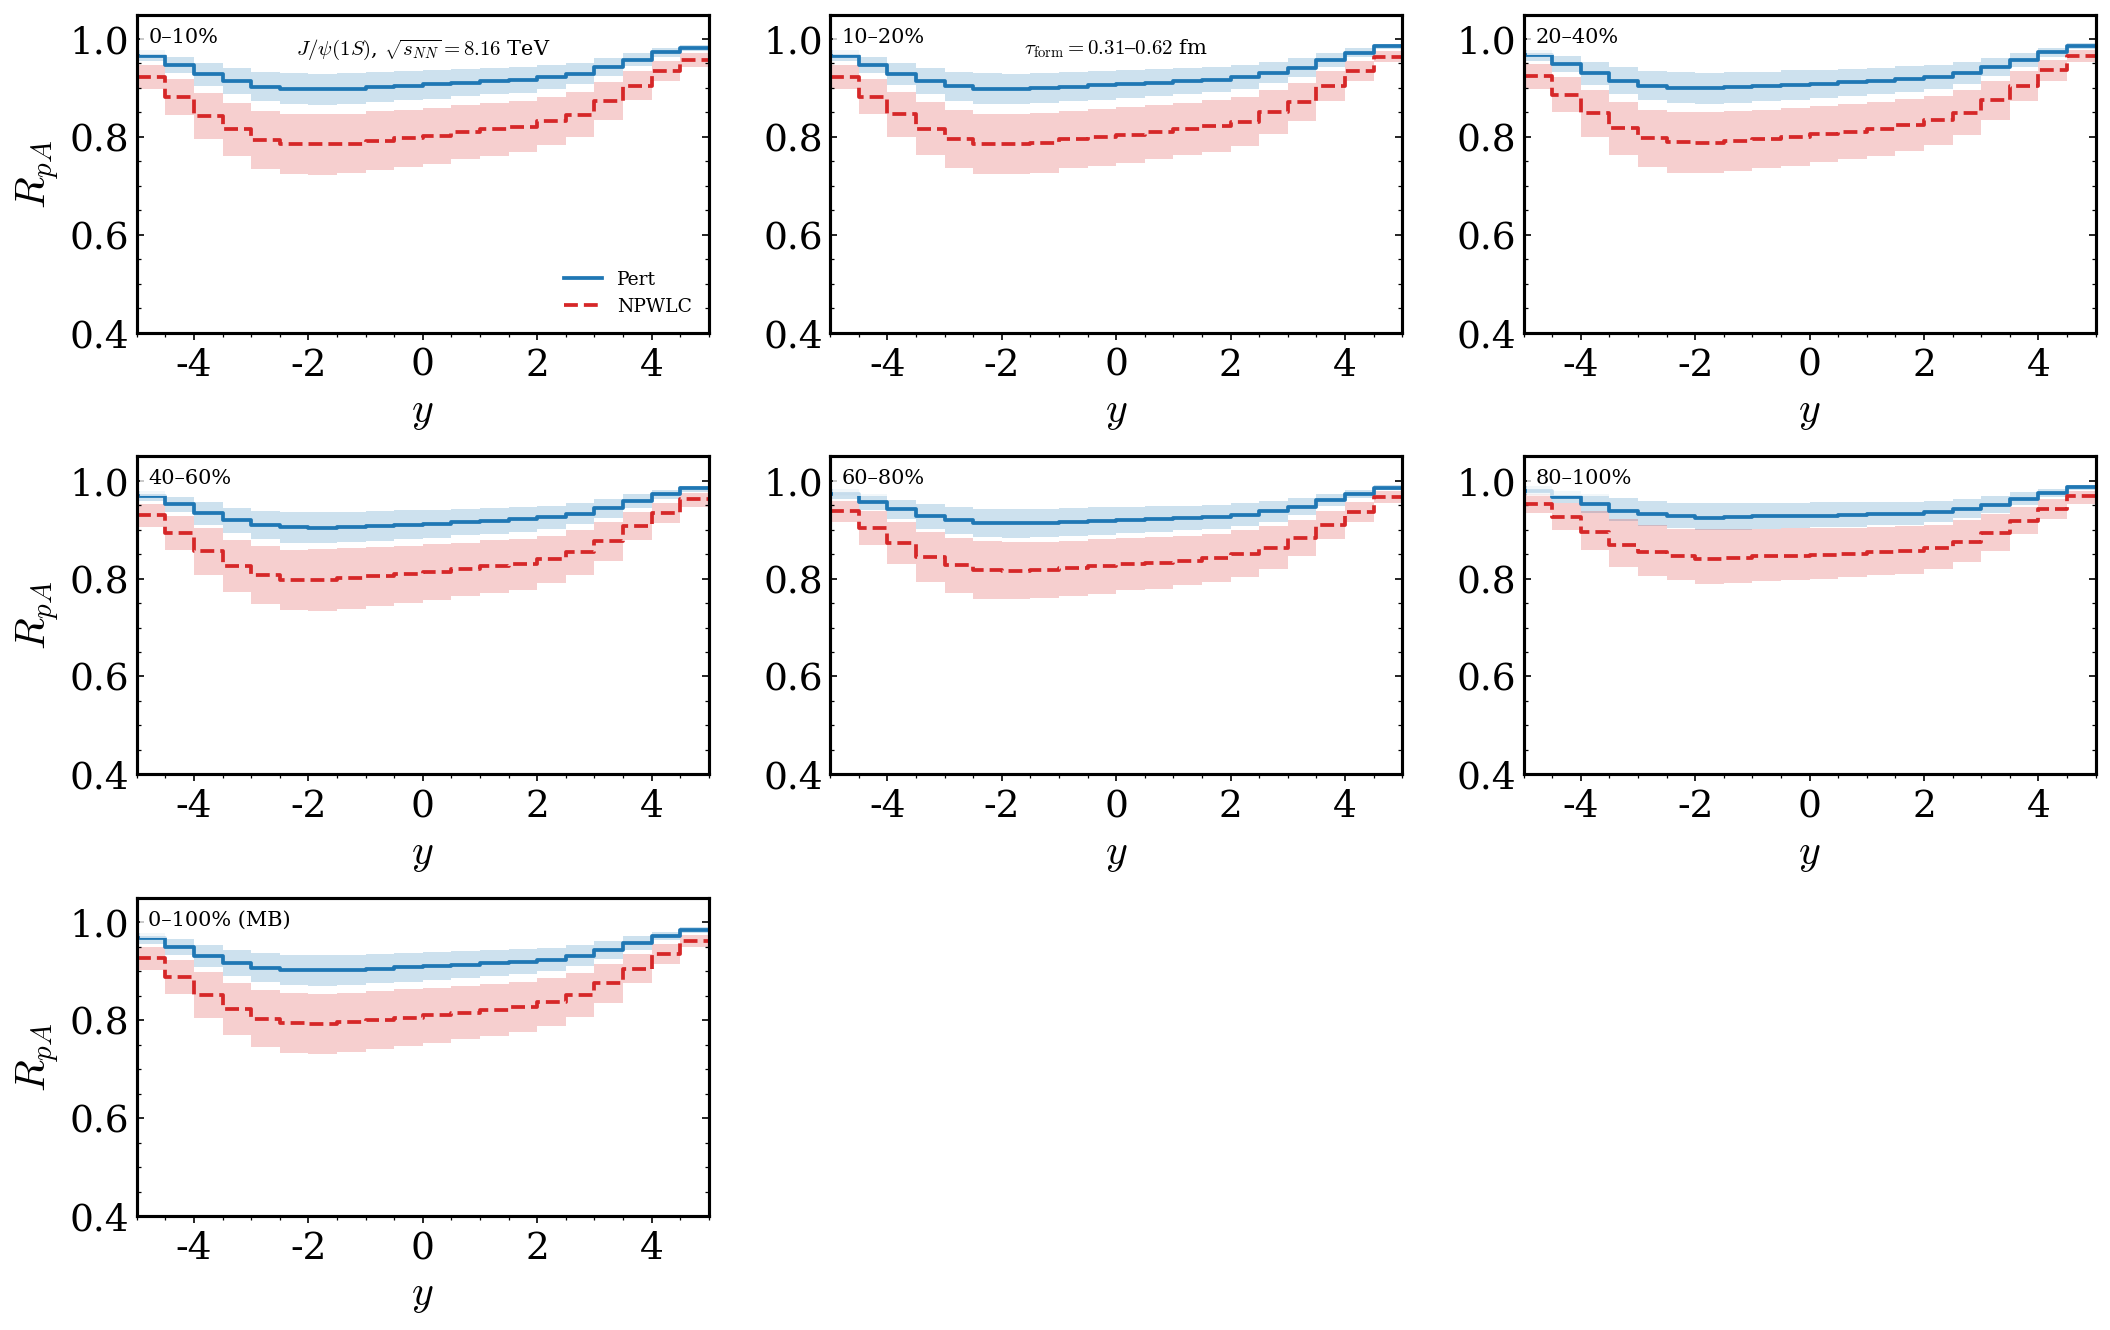

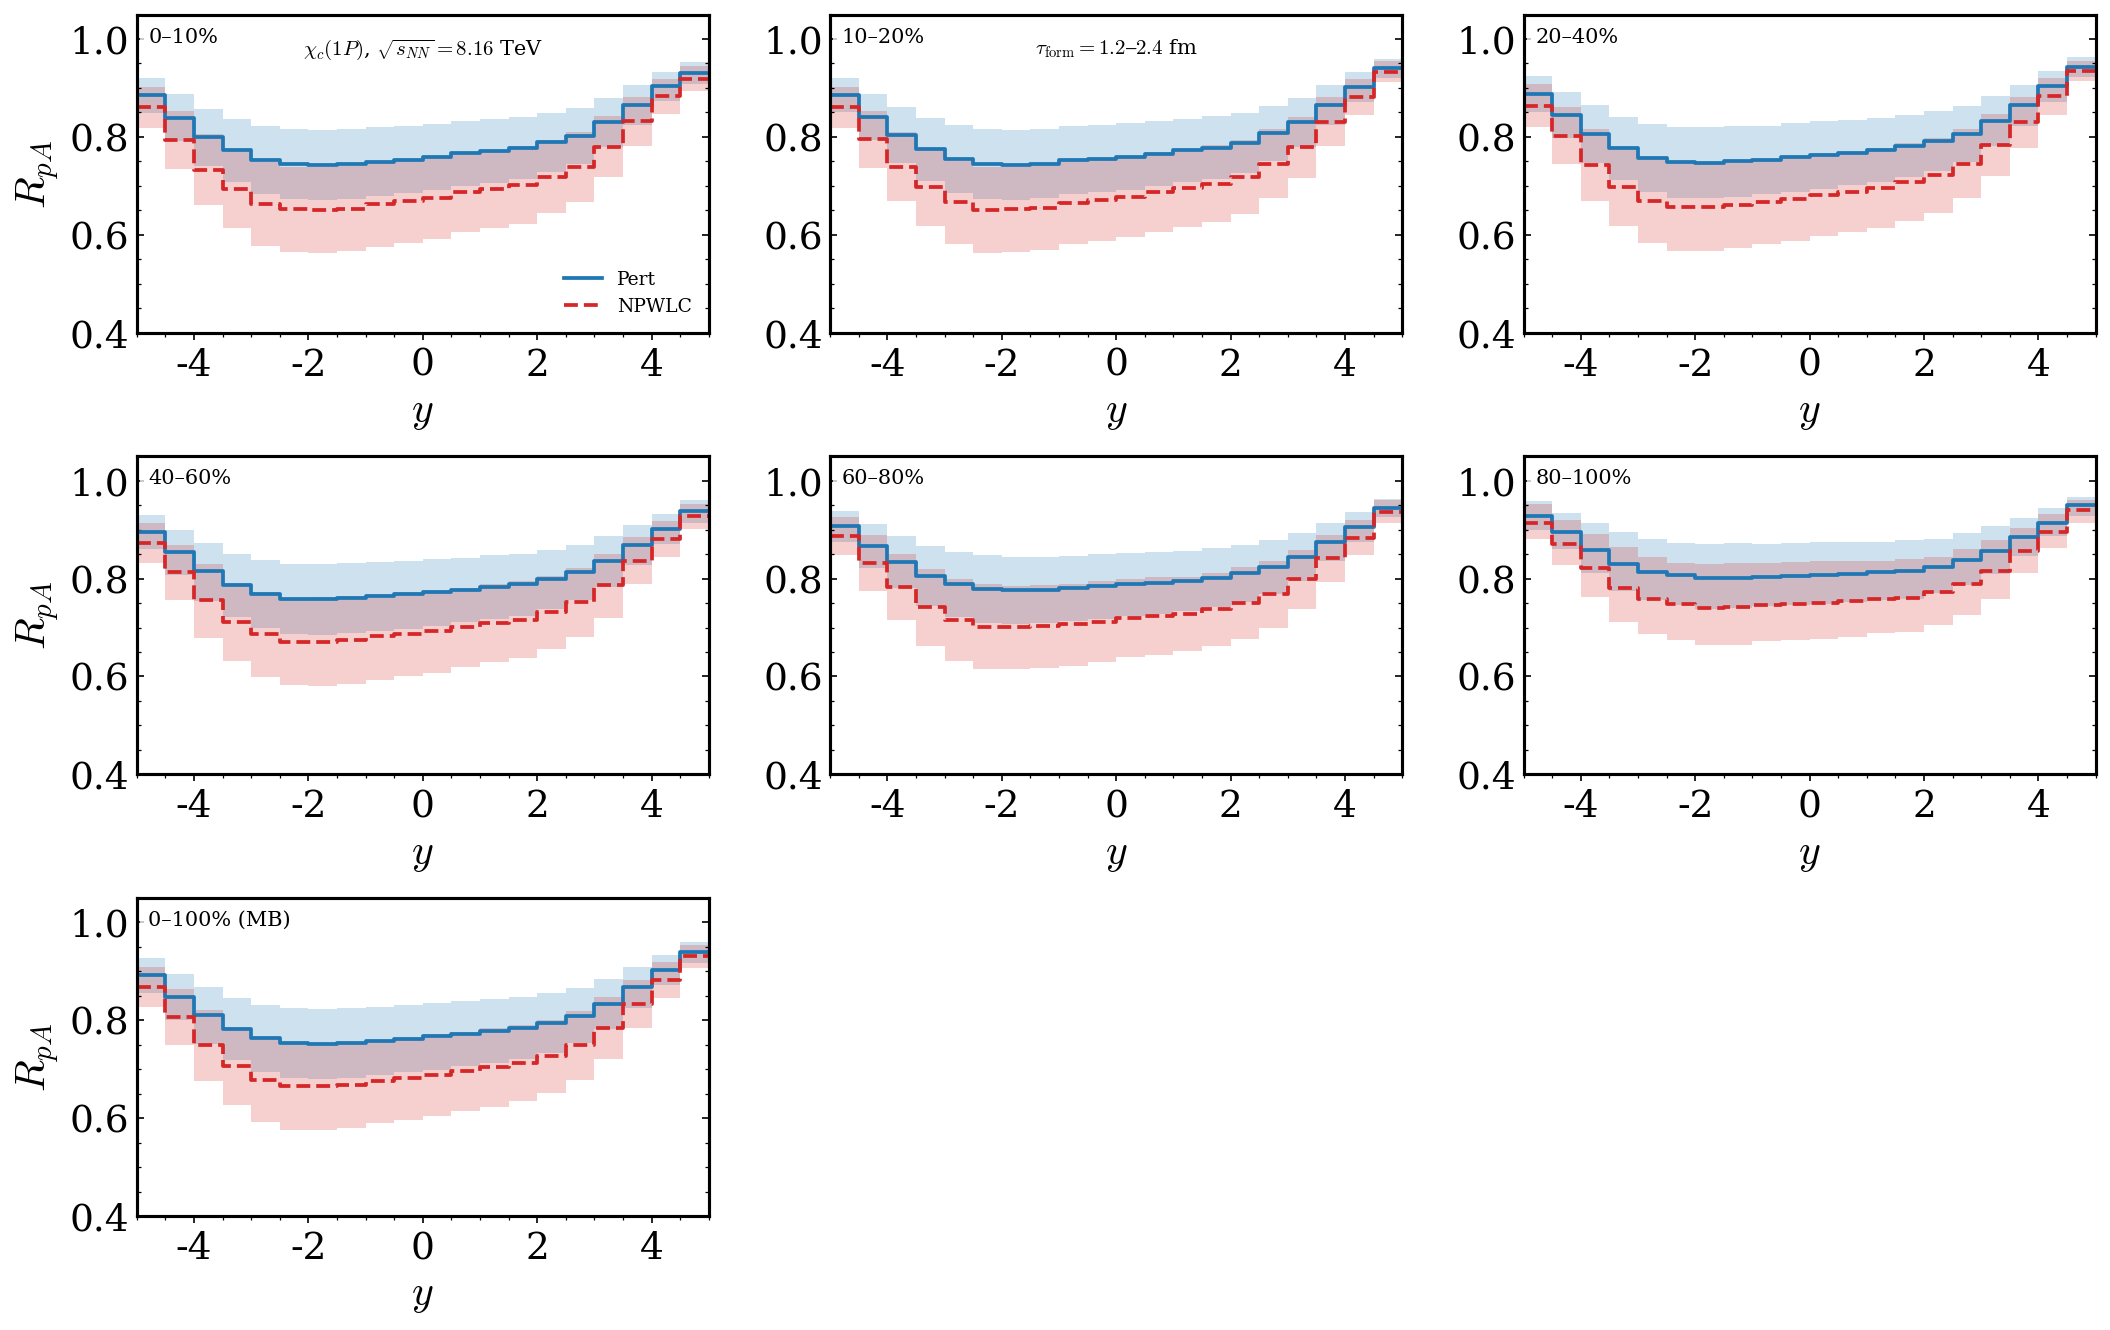

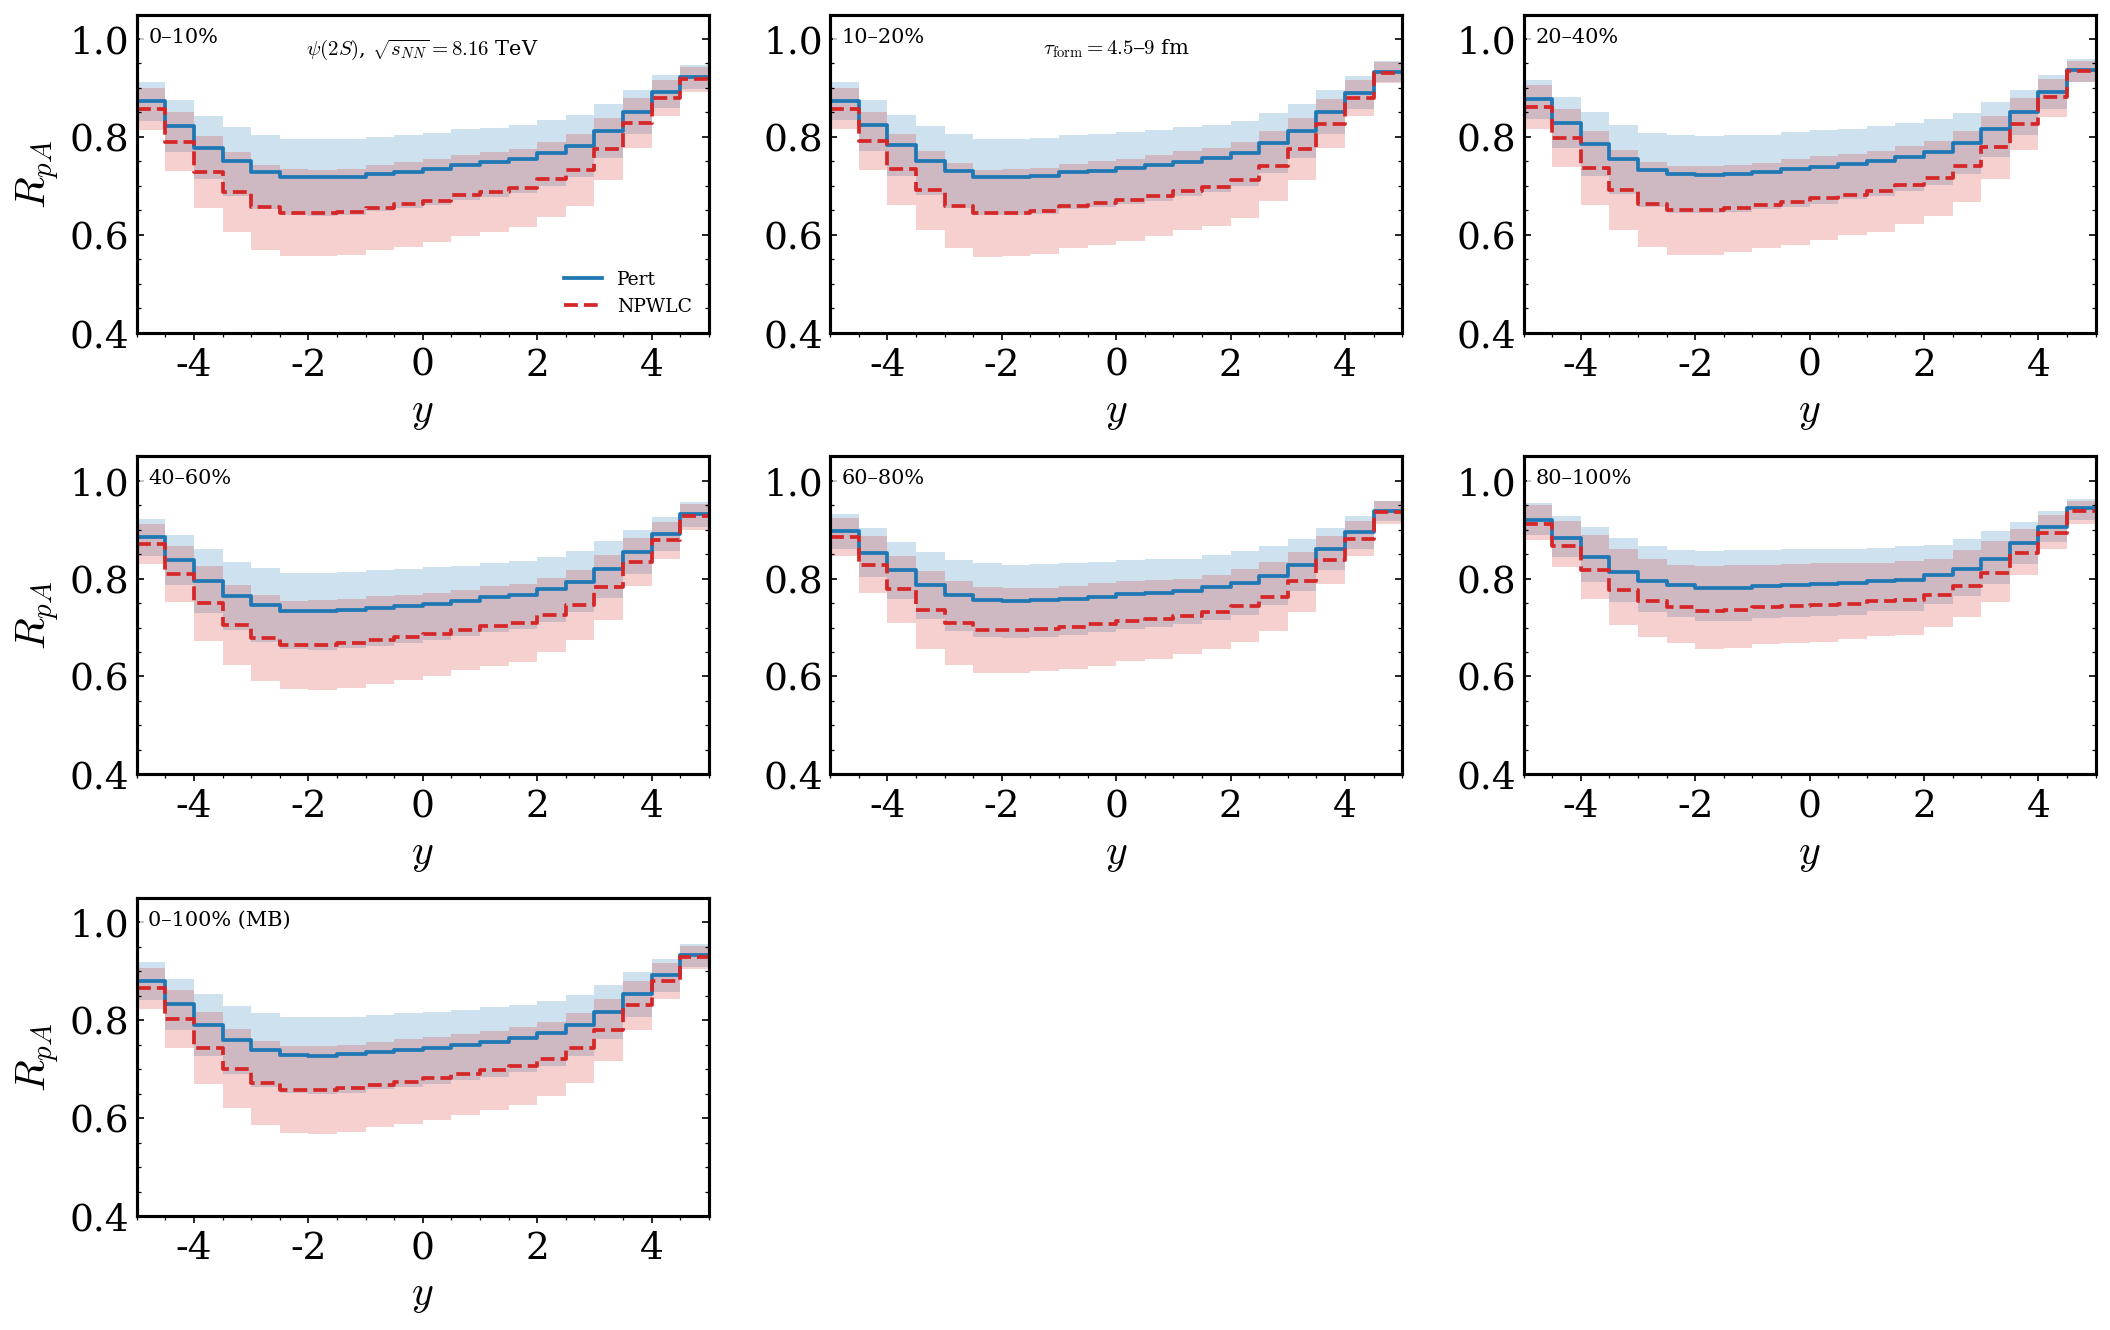

In [ ]:
# --------- Plot: R_pA vs y (all centralities + MB) ---------
for state in PLOT_STATES:
    cent_tags = _sorted_cent_tags(next(iter(prim_y.values())))
    n_cent = len(cent_tags)
    n_cols = 3
    n_rows = int(np.ceil(n_cent / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.8*n_cols, 3.0*n_rows),
        dpi=DPI, sharex=False, sharey=False
    )
    axes = np.atleast_1d(axes).ravel()

    for ip, cent_tag in enumerate(cent_tags):
        ax = axes[ip]
        for model in MODELS:
            if model not in prim_y:
                continue
            if cent_tag not in prim_y[model]:
                continue
            if state not in prim_y[model][cent_tag]:
                continue

            Rc, Rlo, Rhi, y_cent = prim_y[model][cent_tag][state]
            x_edges, y_c  = step_from_centers(y_cent, Rc)
            _,       y_lo = step_from_centers(y_cent, Rlo)
            _,       y_hi = step_from_centers(y_cent, Rhi)

            col = MODEL_COLORS[model]
            ls  = MODEL_LS[model]
            lab = model if ip == 0 else None

            ax.step(x_edges, y_c, where="post", color=col, ls=ls, lw=1.8, label=lab)
            ax.fill_between(
                x_edges, y_lo, y_hi,
                step="post", color=col, alpha=ALPHA_BAND, linewidth=0.0
            )


        # --- MINIMAL CHANGE FIX: TICKS ONLY ---
        ax.minorticks_on()
        # Ensure major ticks show on the right axis
        ax.tick_params(axis='y', which='major', direction='in', right=True) 
        # Ensure minor ticks show on the right axis
        ax.tick_params(axis='y', which='minor', direction='in', right=True)
        # --------------------------------------

        # ax.axhline(1.0, color="k", ls=":", lw=0.8)
        ax.set_xlim(-5, 5)
        ax.set_ylim(0.4, 1.05)
        ax.set_xlabel(r"$y$")
        if ip % n_cols == 0:
            ax.set_ylabel(r"$R_{pA}$")
        ax.grid(False)

        ax.text(
            0.02, 0.96, cent_tag,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
        )

    for k in range(n_cent, len(axes)):
        axes[k].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(handles, labels, loc="lower right", fontsize=9, frameon=False)

    tau_lo, tau_hi = TAUFORM[state]

    # Line 1: State and Sqrt(s_NN)
    note_line1 = rf"{STATE_LABELS[state]}, $\sqrt{{s_{{NN}}}}={float(ENERGY):.2f}$ TeV"
    axes[0].text(
        0.50, 0.93, note_line1,
        transform=axes[0].transAxes,
        ha="center", va="top",
        fontsize=10  # Use the standard font size
    )
    
    # Line 2: Tau form
    note_line2 = rf"$\tau_{{\rm form}}={tau_lo:.2g}\text{{–}}{tau_hi:.2g}$ fm"
    axes[1].text(
        0.50, 0.93, note_line2, # Lowered position (0.88 - 0.07)
        transform=axes[1].transAxes,
        ha="center", va="top",
        fontsize=10
    )
    
    fig.tight_layout()
    if SAVE_PDF:
        fig.savefig(
            outdir / f"primordial_RpA_vs_y_{state}_{ENERGY.replace('.','p')}TeV.pdf",
            bbox_inches="tight"
        )

    if SAVE_CSV:
        rows = []
        for model in MODELS:
            if model not in prim_y:
                continue
            for cent_tag in prim_y[model]:
                if state not in prim_y[model][cent_tag]:
                    continue
                Rc, Rlo, Rhi, y_cent = prim_y[model][cent_tag][state]
                for yv, rc, rlo, rhi in zip(y_cent, Rc, Rlo, Rhi):
                    rows.append({
                        "energy": ENERGY,
                        "model":  model,
                        "centrality": cent_tag,
                        "state": state,
                        "y": yv,
                        "R": rc,
                        "R_lo": rlo,
                        "R_hi": rhi,
                    })
        if rows:
            df_out = pd.DataFrame(rows)
            df_out.to_csv(
                outdir / f"primordial_RpA_vs_y_{state}_{ENERGY.replace('.','p')}TeV.csv",
                index=False,
            )


## $R_{pA}$ vs Transverse Momentum

In [ ]:
# ======================================================================
#  R_pA vs pT   (MB again from centrality slices)
# ======================================================================

prim_pt = {}  # prim_pt[yname][model][cent_tag][state] = (Rc,Rlo,Rhi,pT_cent)

def primordial_vs_pT_all(
    combos,
    states=STATES,
    cent_classes=CENT_CLASSES,
    y_wins=Y_WINDOWS,
    pt_bins=PT_BINS,
):
    """
    For each y-window, model, and centrality (including MB),
    compute R_pA(pT) using per-b results and N_coll-based centrality weights.
    """
    out = {}
    for yname, y0, y1 in _iter_ywins(y_wins):
        out[yname] = {c.model: {} for c in combos}

        for combo in combos:
            maps = _maps_from_runs(combo.runs)

            dfC_b, dfB_b = combo.ens.central_and_band_vs_pt_per_b(
                y_window=(y0, y1, yname),
                pt_bins=pt_bins,
                with_feeddown=True,
                use_nbin=True,
            )

            slice_w = _centrality_slice_weights(maps, dfC_b, cent_classes, scheme="nbin")
            cent_tags_for_weights = []

            # ---- centrality slices ----
            for ic, (lo, hi) in enumerate(cent_classes):
                tag = f"{int(lo)}–{int(hi)}%"
                dfc, dfb = _aggregate_class(
                    dfC_b, dfB_b, maps, lo, hi, states, "pt"
                )
                if dfc is None:
                    continue

                pT_cent = dfc["pt"].to_numpy(float)
                entry = {}
                for s in states:
                    Rc = dfc[s].to_numpy(float)
                    if dfb is not None and f"{s}_lo" in dfb:
                        Rlo = dfb[f"{s}_lo"].to_numpy(float)
                        Rhi = dfb[f"{s}_hi"].to_numpy(float)
                    else:
                        Rlo = Rc
                        Rhi = Rc
                    entry[s] = (Rc, Rlo, Rhi, pT_cent)
                out[yname][combo.model][tag] = entry
                cent_tags_for_weights.append((tag, ic))

            # ---- MB from centrality slices ----
            tag_mb = "0–100% (MB)"
            entry_mb = {}

            for s in states:
                pT_ref = None
                Rc_slices, Rlo_slices, Rhi_slices = [], [], []
                w_used = []

                for tag, ic in cent_tags_for_weights:
                    if s not in out[yname][combo.model].get(tag, {}):
                        continue
                    Rc, Rlo, Rhi, pT_cent = out[yname][combo.model][tag][s]
                    # if pT_ref is None:
                    #     pT_ref = pT_cent
                    # else:
                    #     if len(pT_cent) != len(pT_ref) or not np.allclose(pT_cent, pT_ref):
                    #         raise RuntimeError("pT-bin mismatch between centrality slices")
                    if pT_ref is None:
                        # Use the first slice as the reference grid.
                        pT_ref = pT_cent
                    else:
                        # If later slices have fewer points (e.g. 5 instead of 6),
                        # we'll truncate to the common length after the loop.
                        # We assume the bins are aligned from low pT upwards.
                        pass

                    Rc_slices.append(Rc)
                    Rlo_slices.append(Rlo)
                    Rhi_slices.append(Rhi)
                    w_used.append(slice_w[ic])

                if not Rc_slices:
                    continue

                W = np.asarray(w_used, float)
                W /= W.sum()

                # NEW: enforce a common length across slices
                min_len = min(len(arr) for arr in Rc_slices)
                # Assume bins are aligned from low pT; drop any extra tail points
                pT_ref_common = pT_ref[:min_len]

                Rc_stack  = np.stack([arr[:min_len] for arr in Rc_slices],  axis=0)
                Rlo_stack = np.stack([arr[:min_len] for arr in Rlo_slices], axis=0)
                Rhi_stack = np.stack([arr[:min_len] for arr in Rhi_slices], axis=0)

                Rc_MB  = np.tensordot(W, Rc_stack,  axes=(0,0))
                Rlo_MB = np.tensordot(W, Rlo_stack, axes=(0,0))
                Rhi_MB = np.tensordot(W, Rhi_stack, axes=(0,0))

                entry_mb[s] = (Rc_MB, Rlo_MB, Rhi_MB, pT_ref_common)

            if entry_mb:
                out[yname][combo.model][tag_mb] = entry_mb

    return out

prim_pt = primordial_vs_pT_all(present)

YLIMS_PT = {
    "forward":  (0.4, 1.1),
    "central":  (0.4, 1.1),
    "backward": (0.4, 1.1),
}


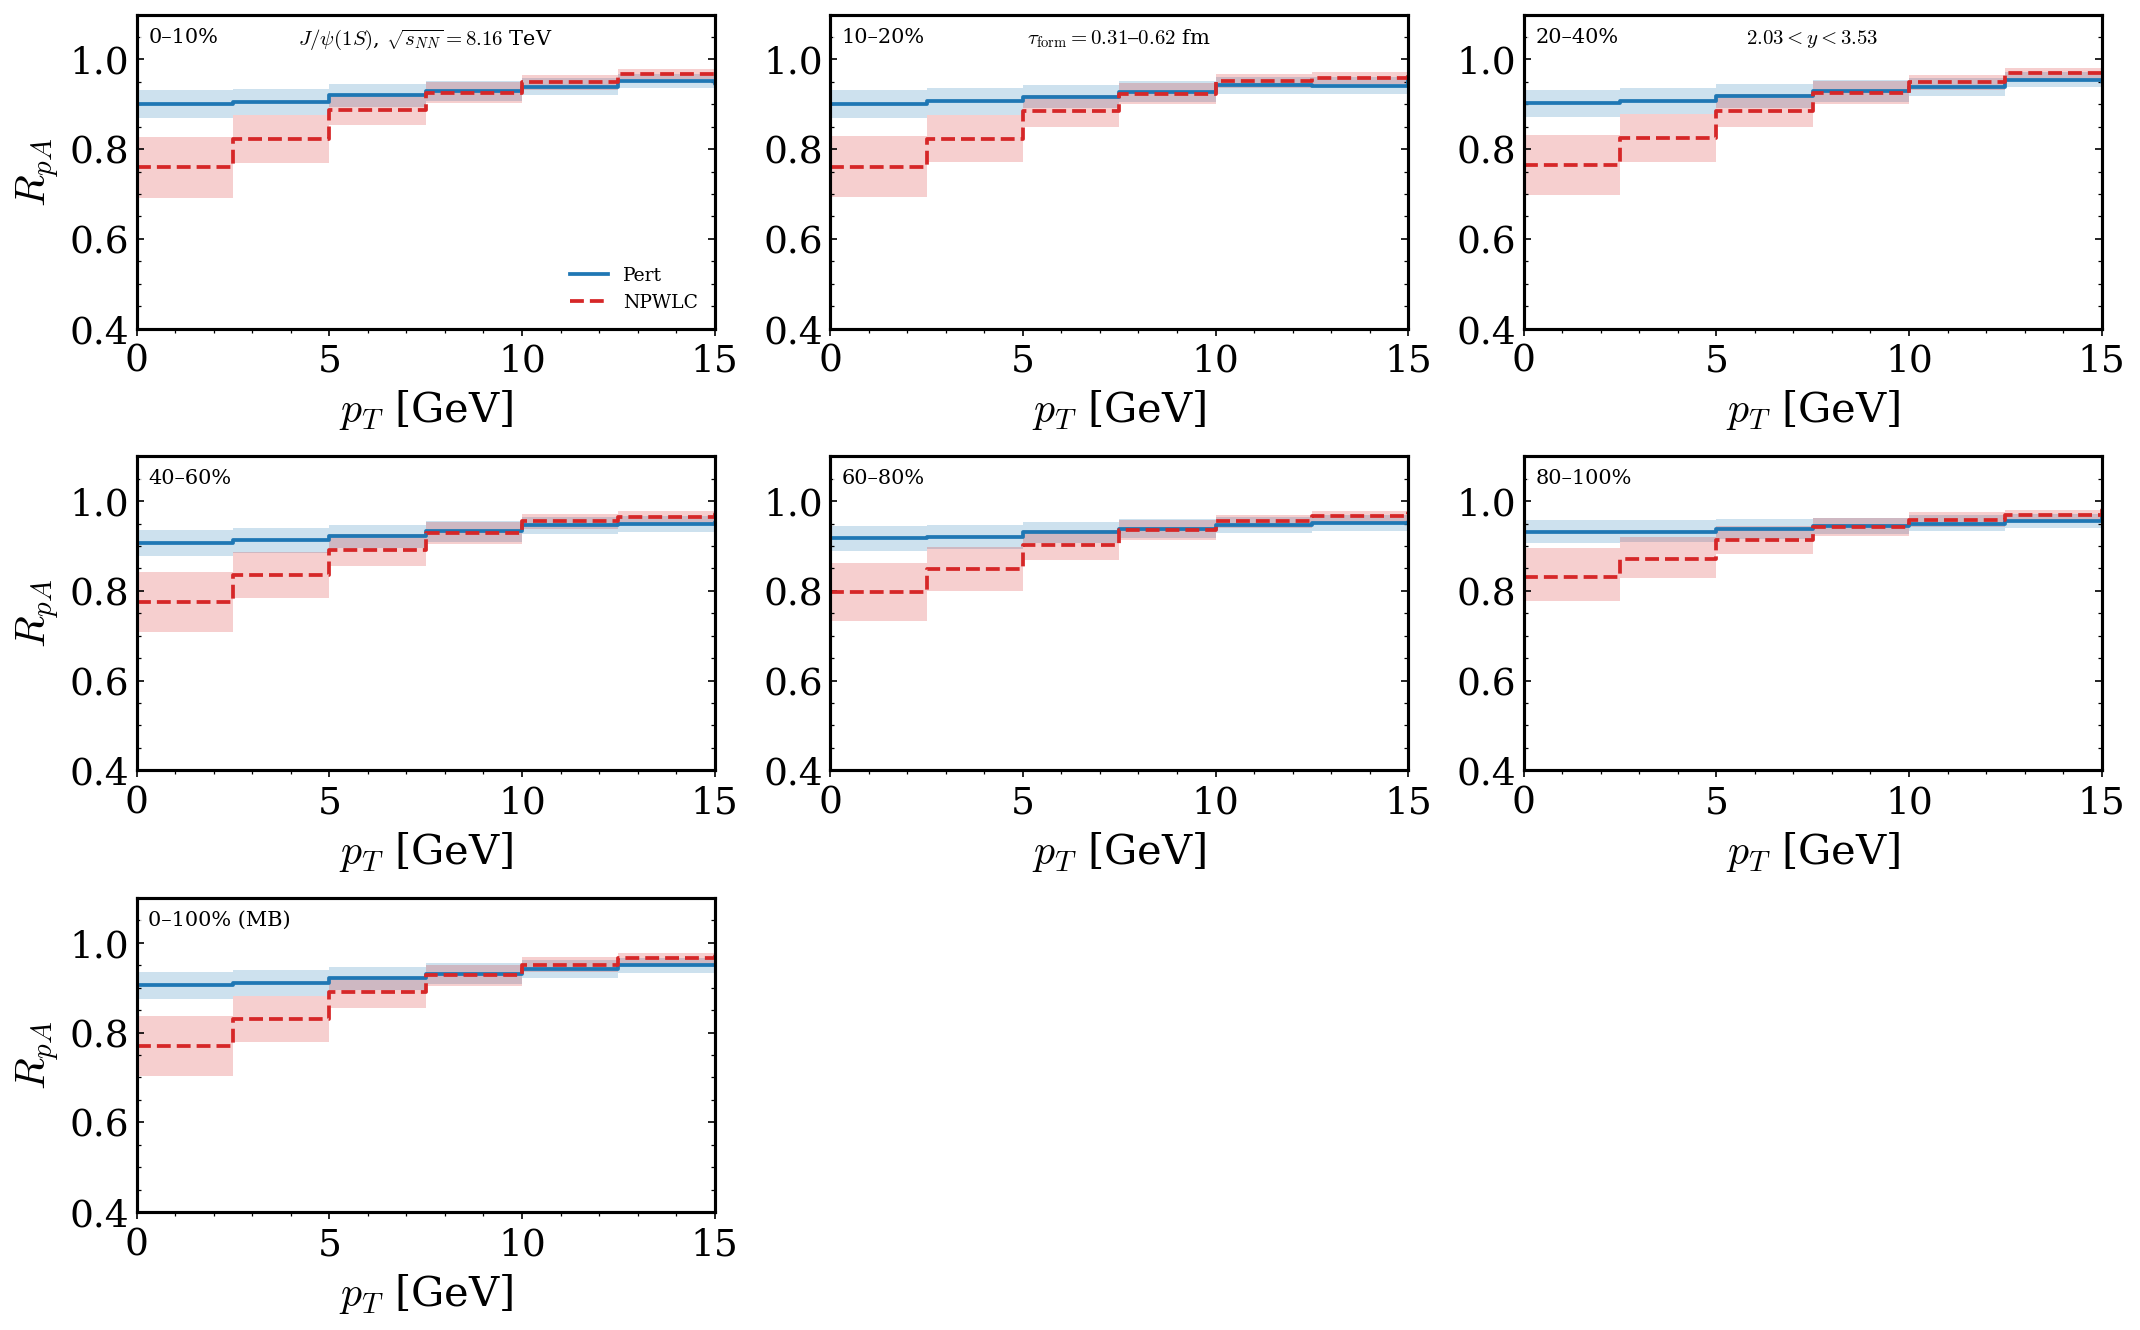

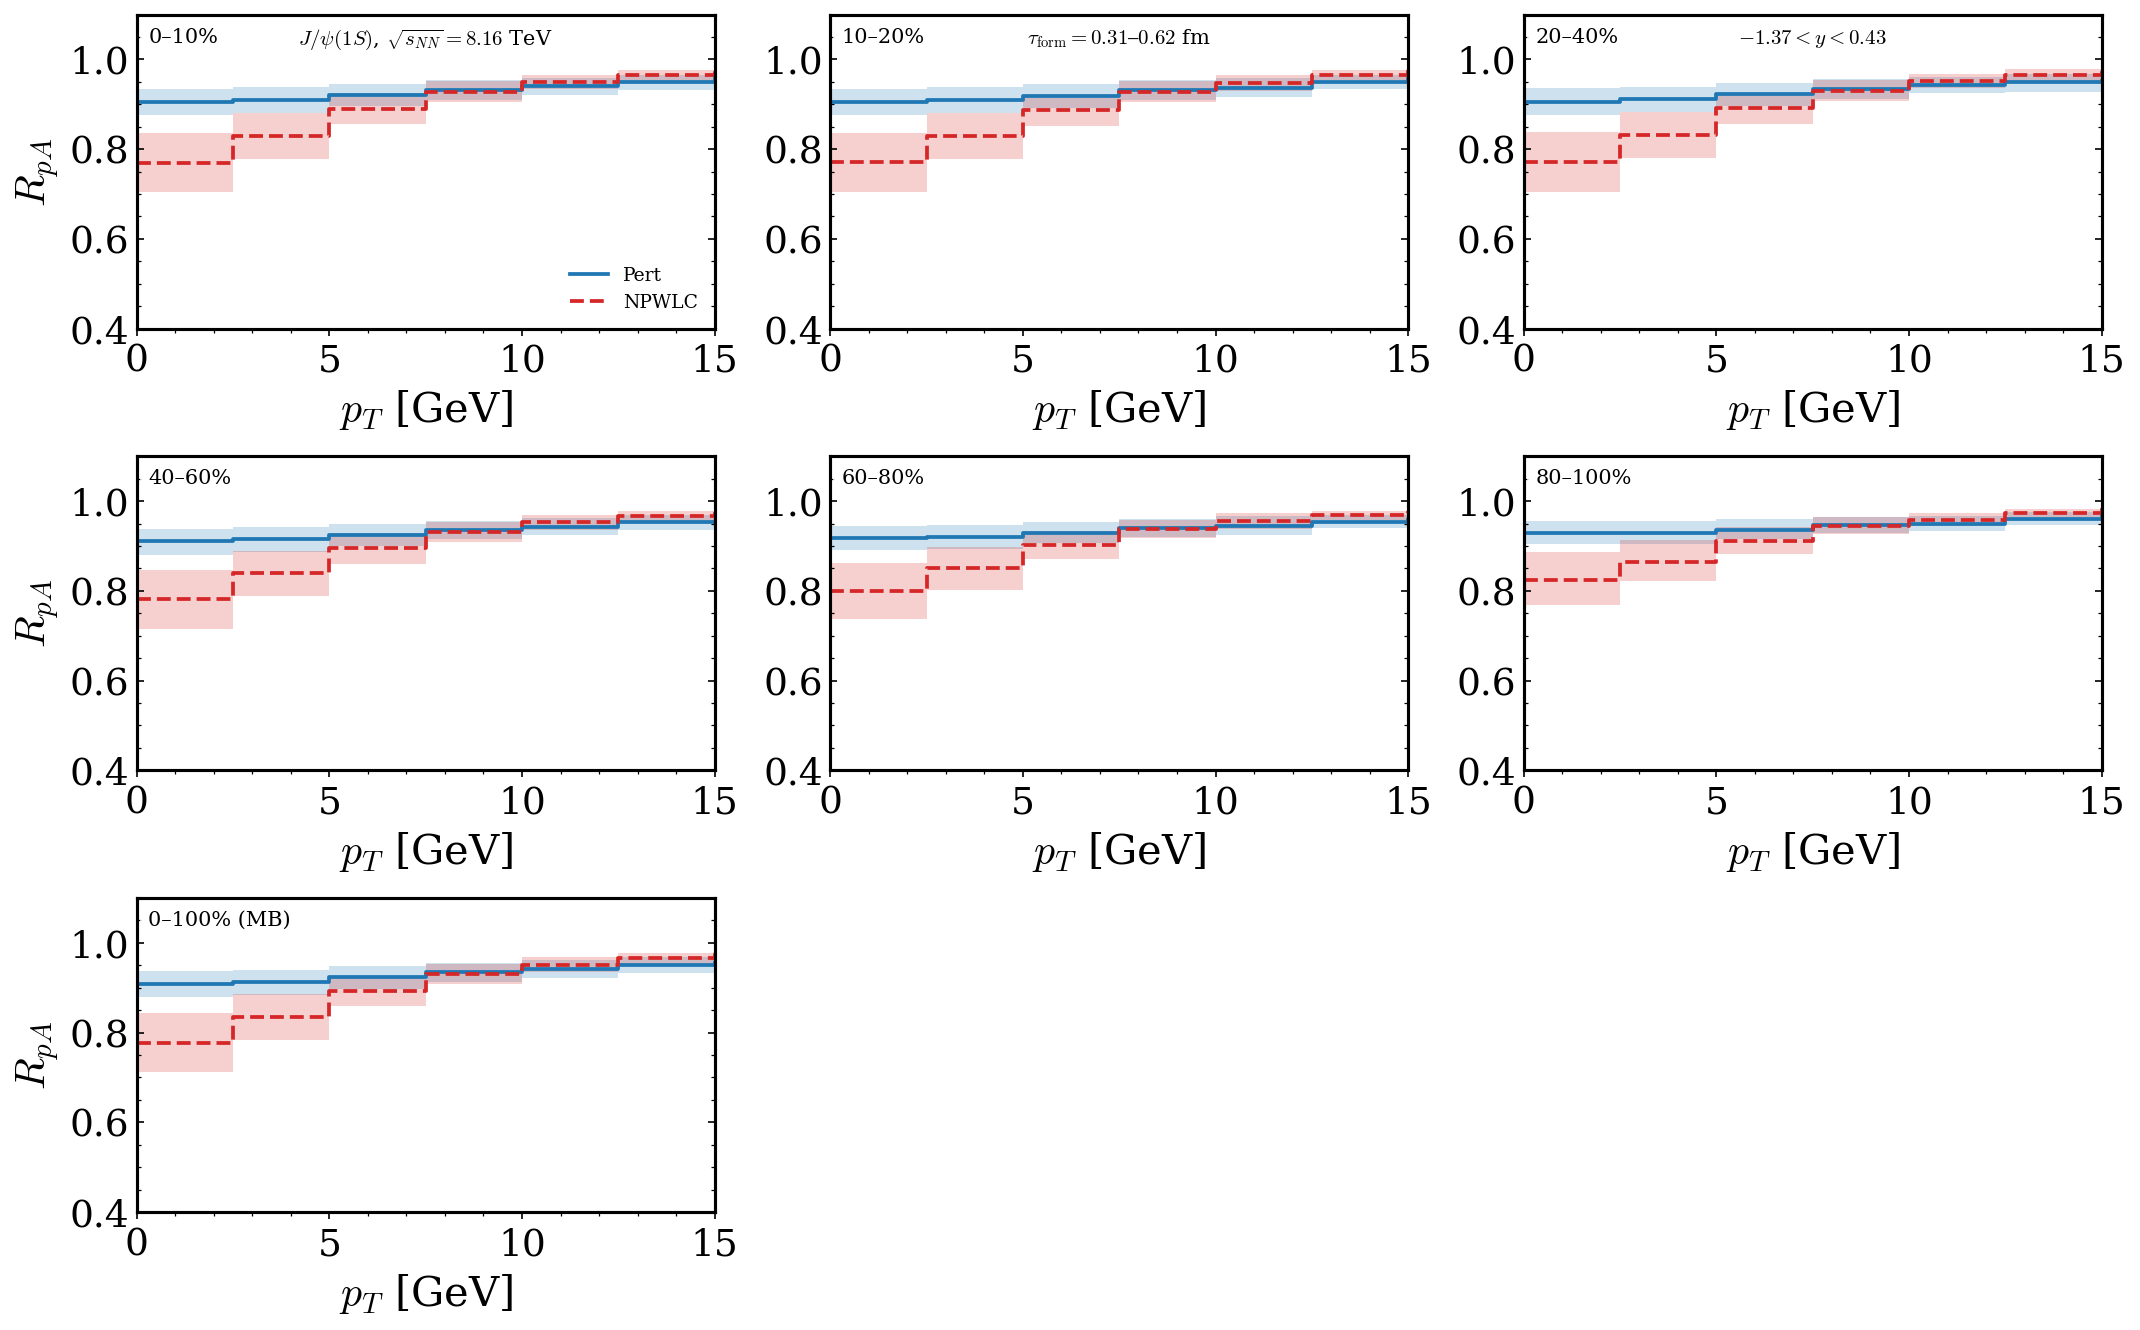

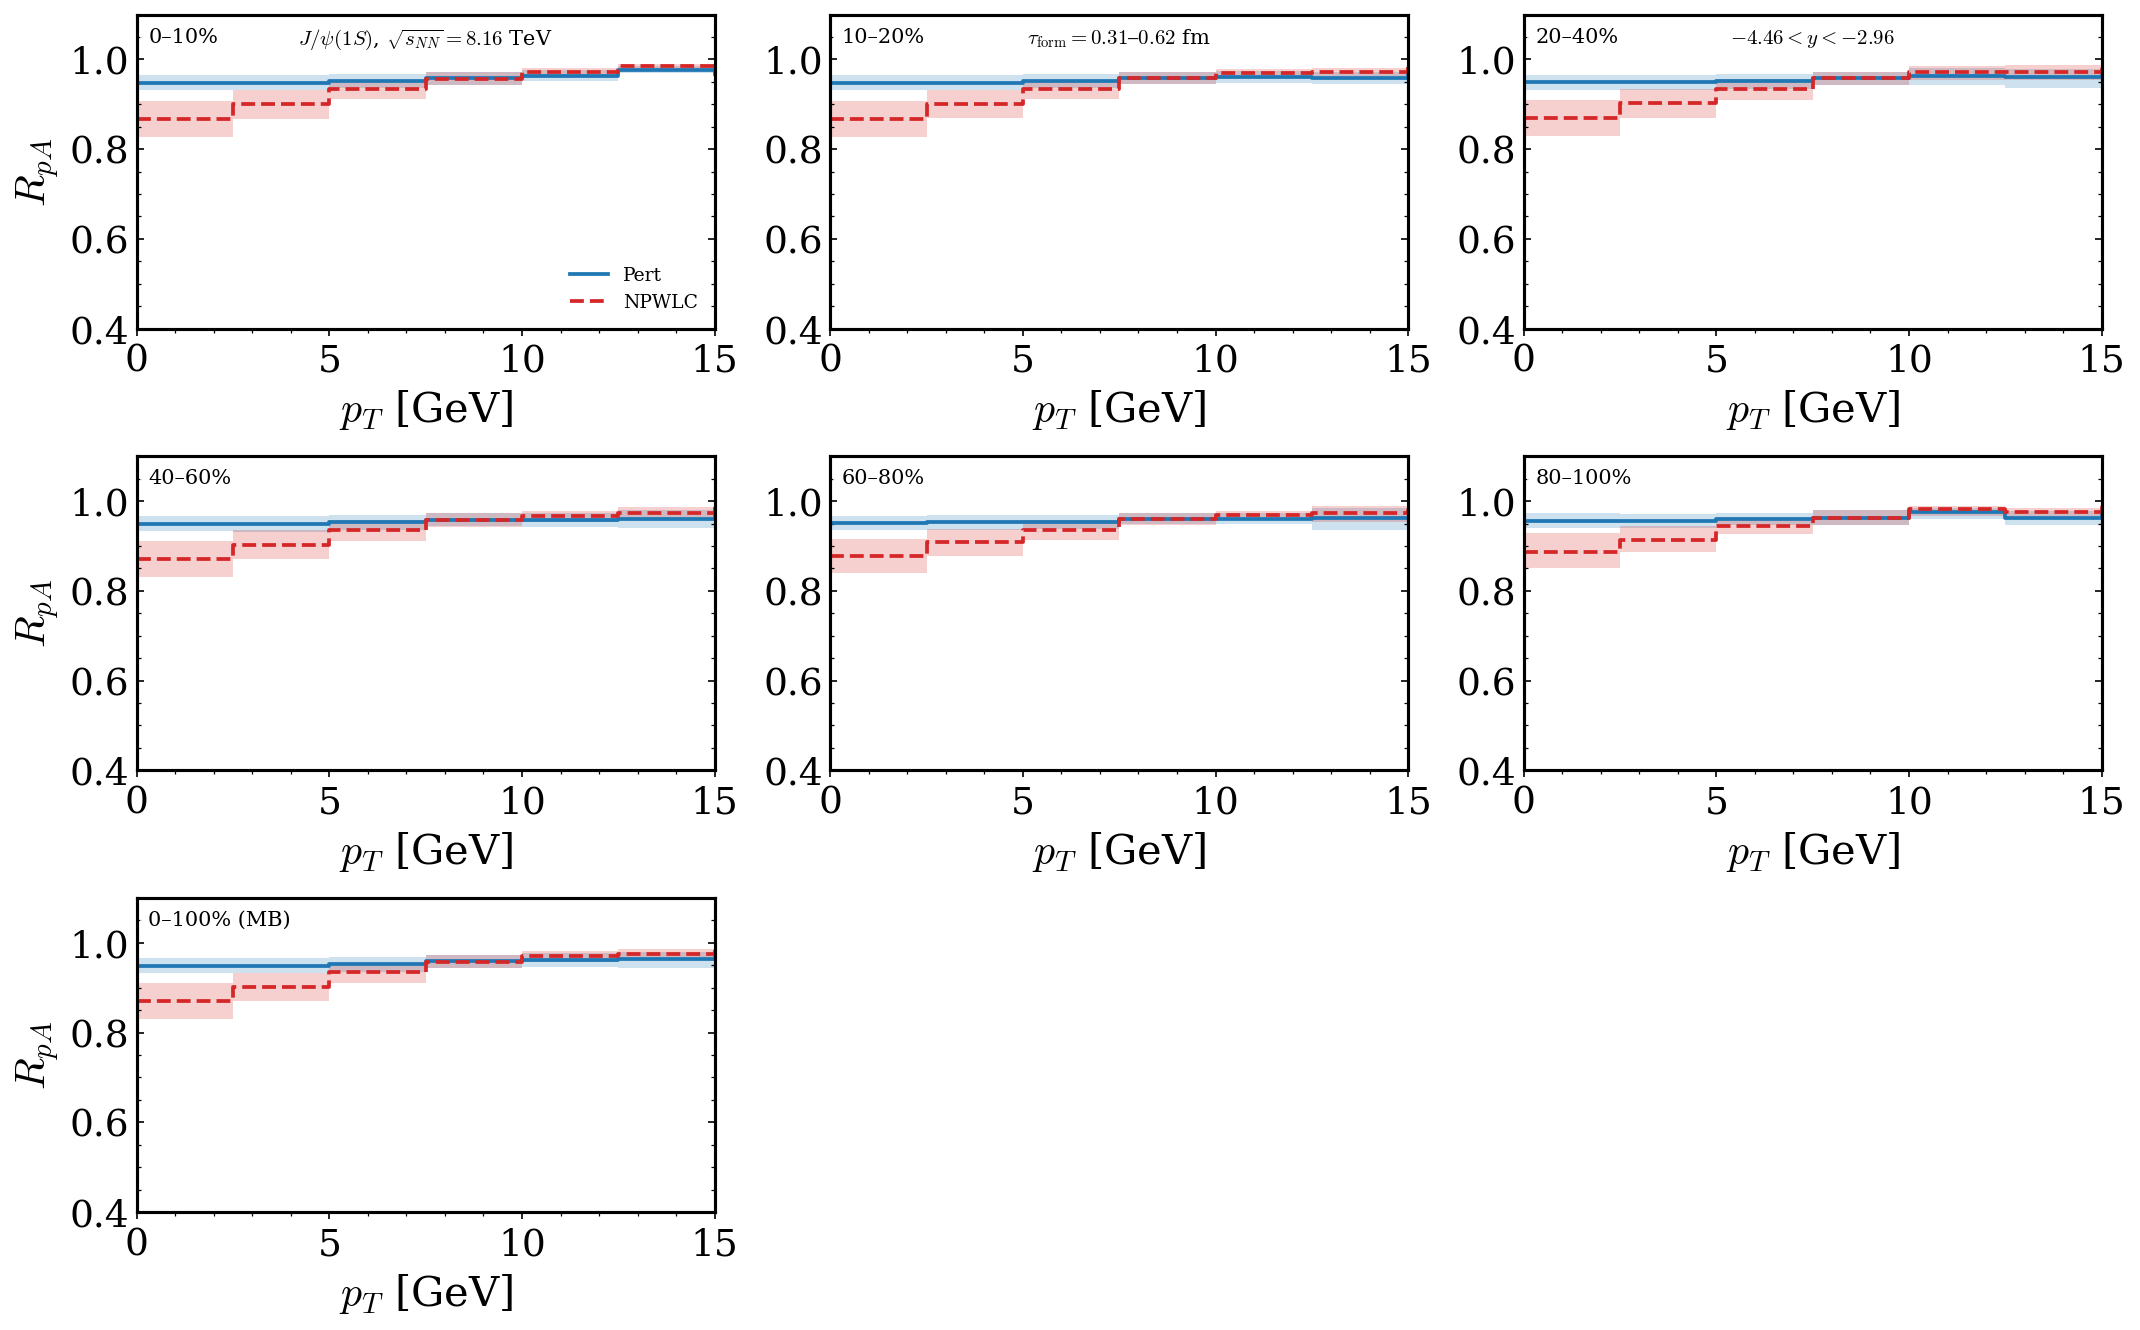

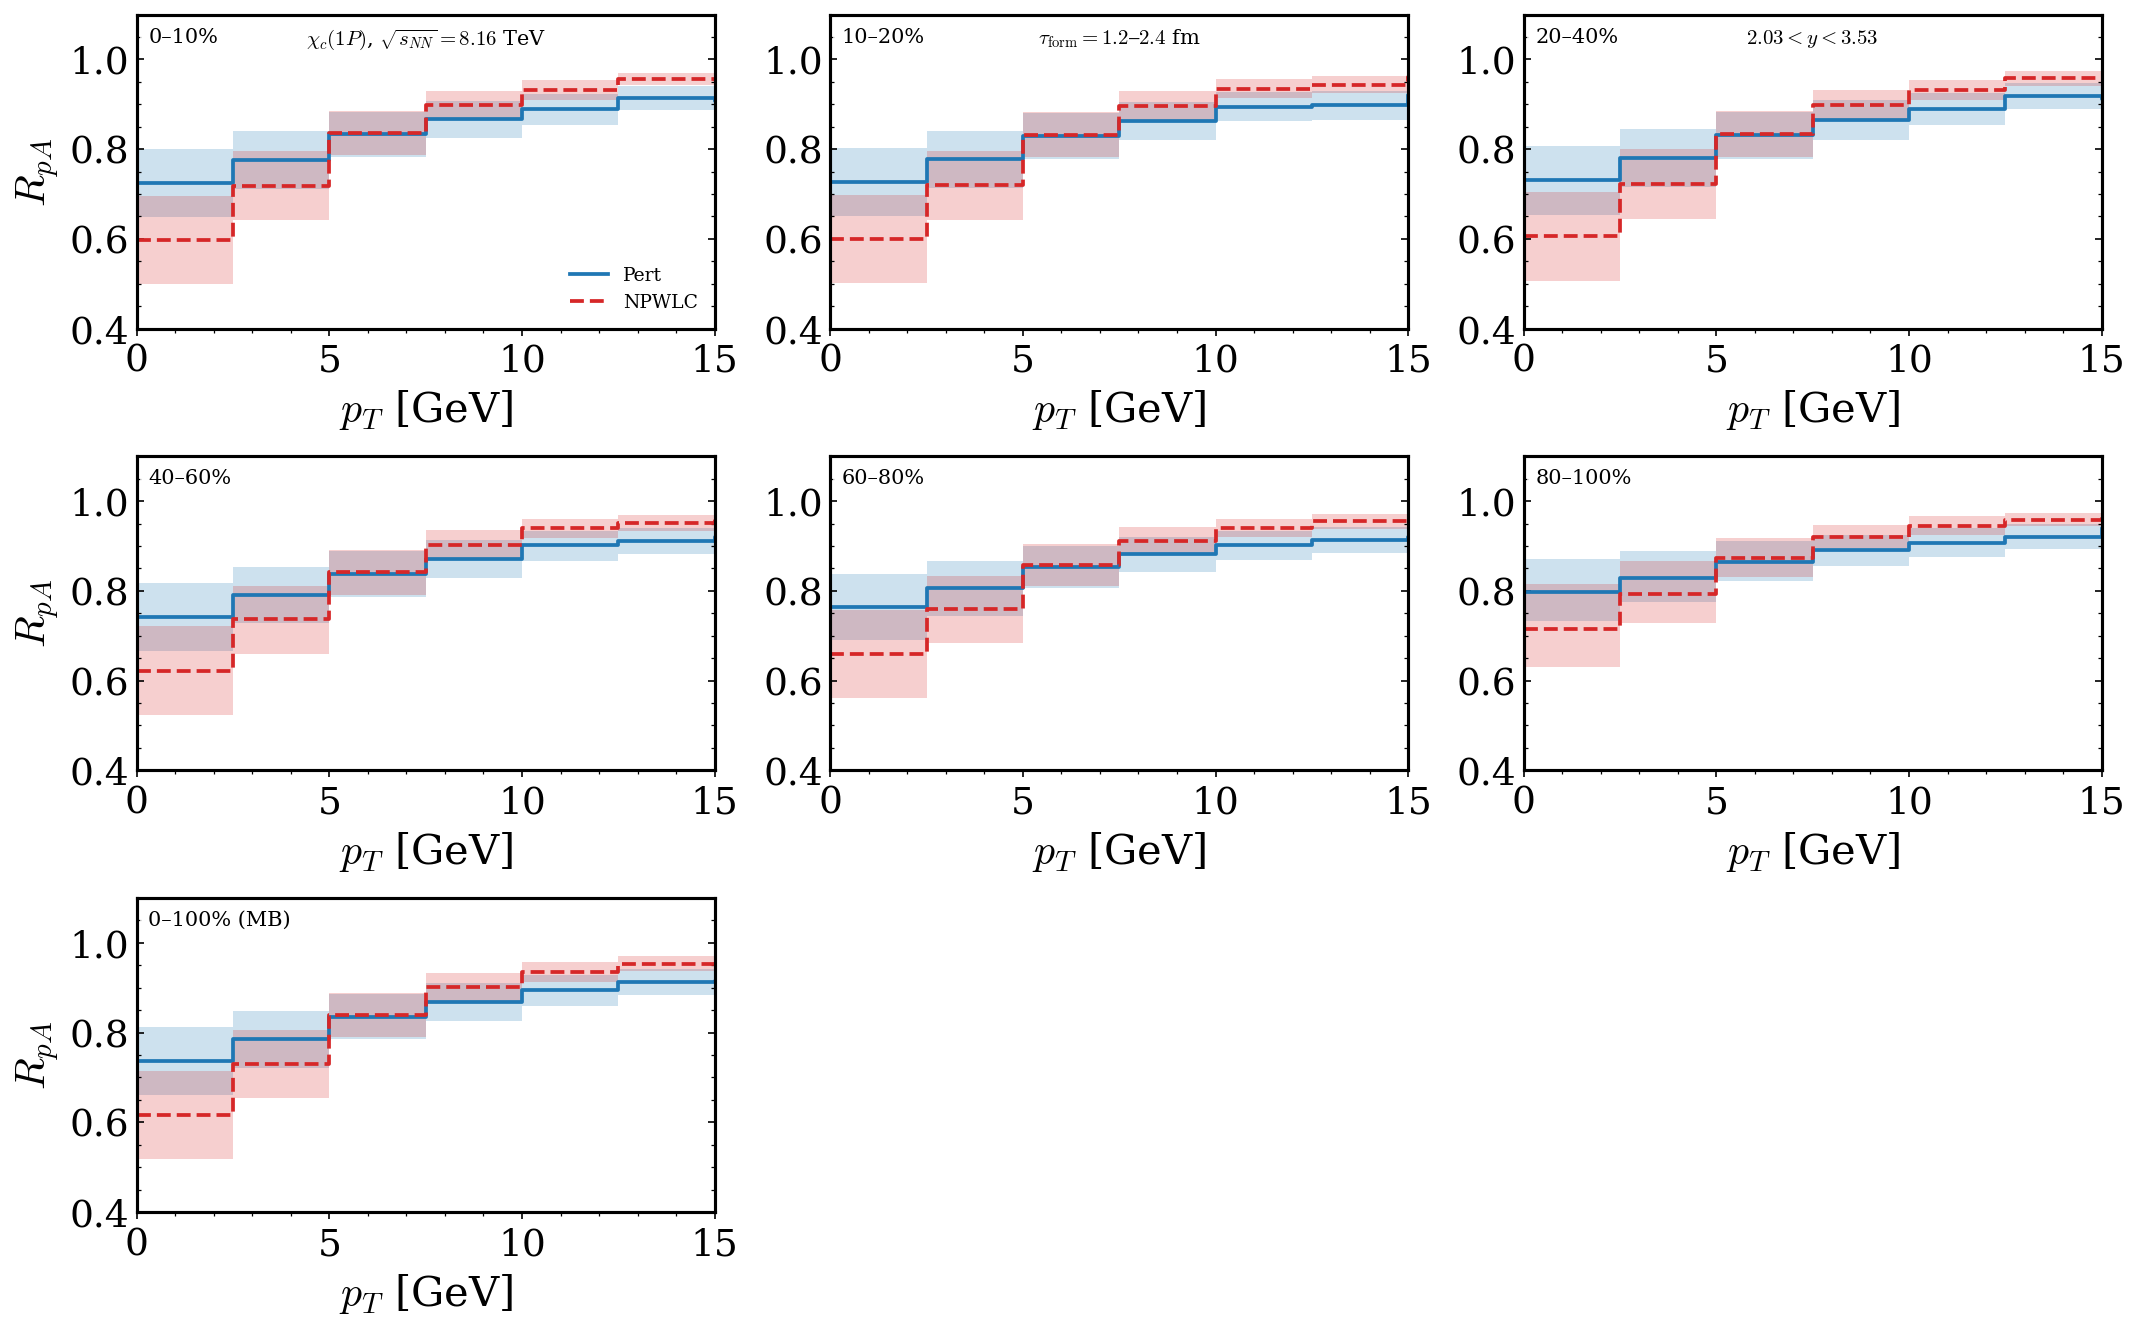

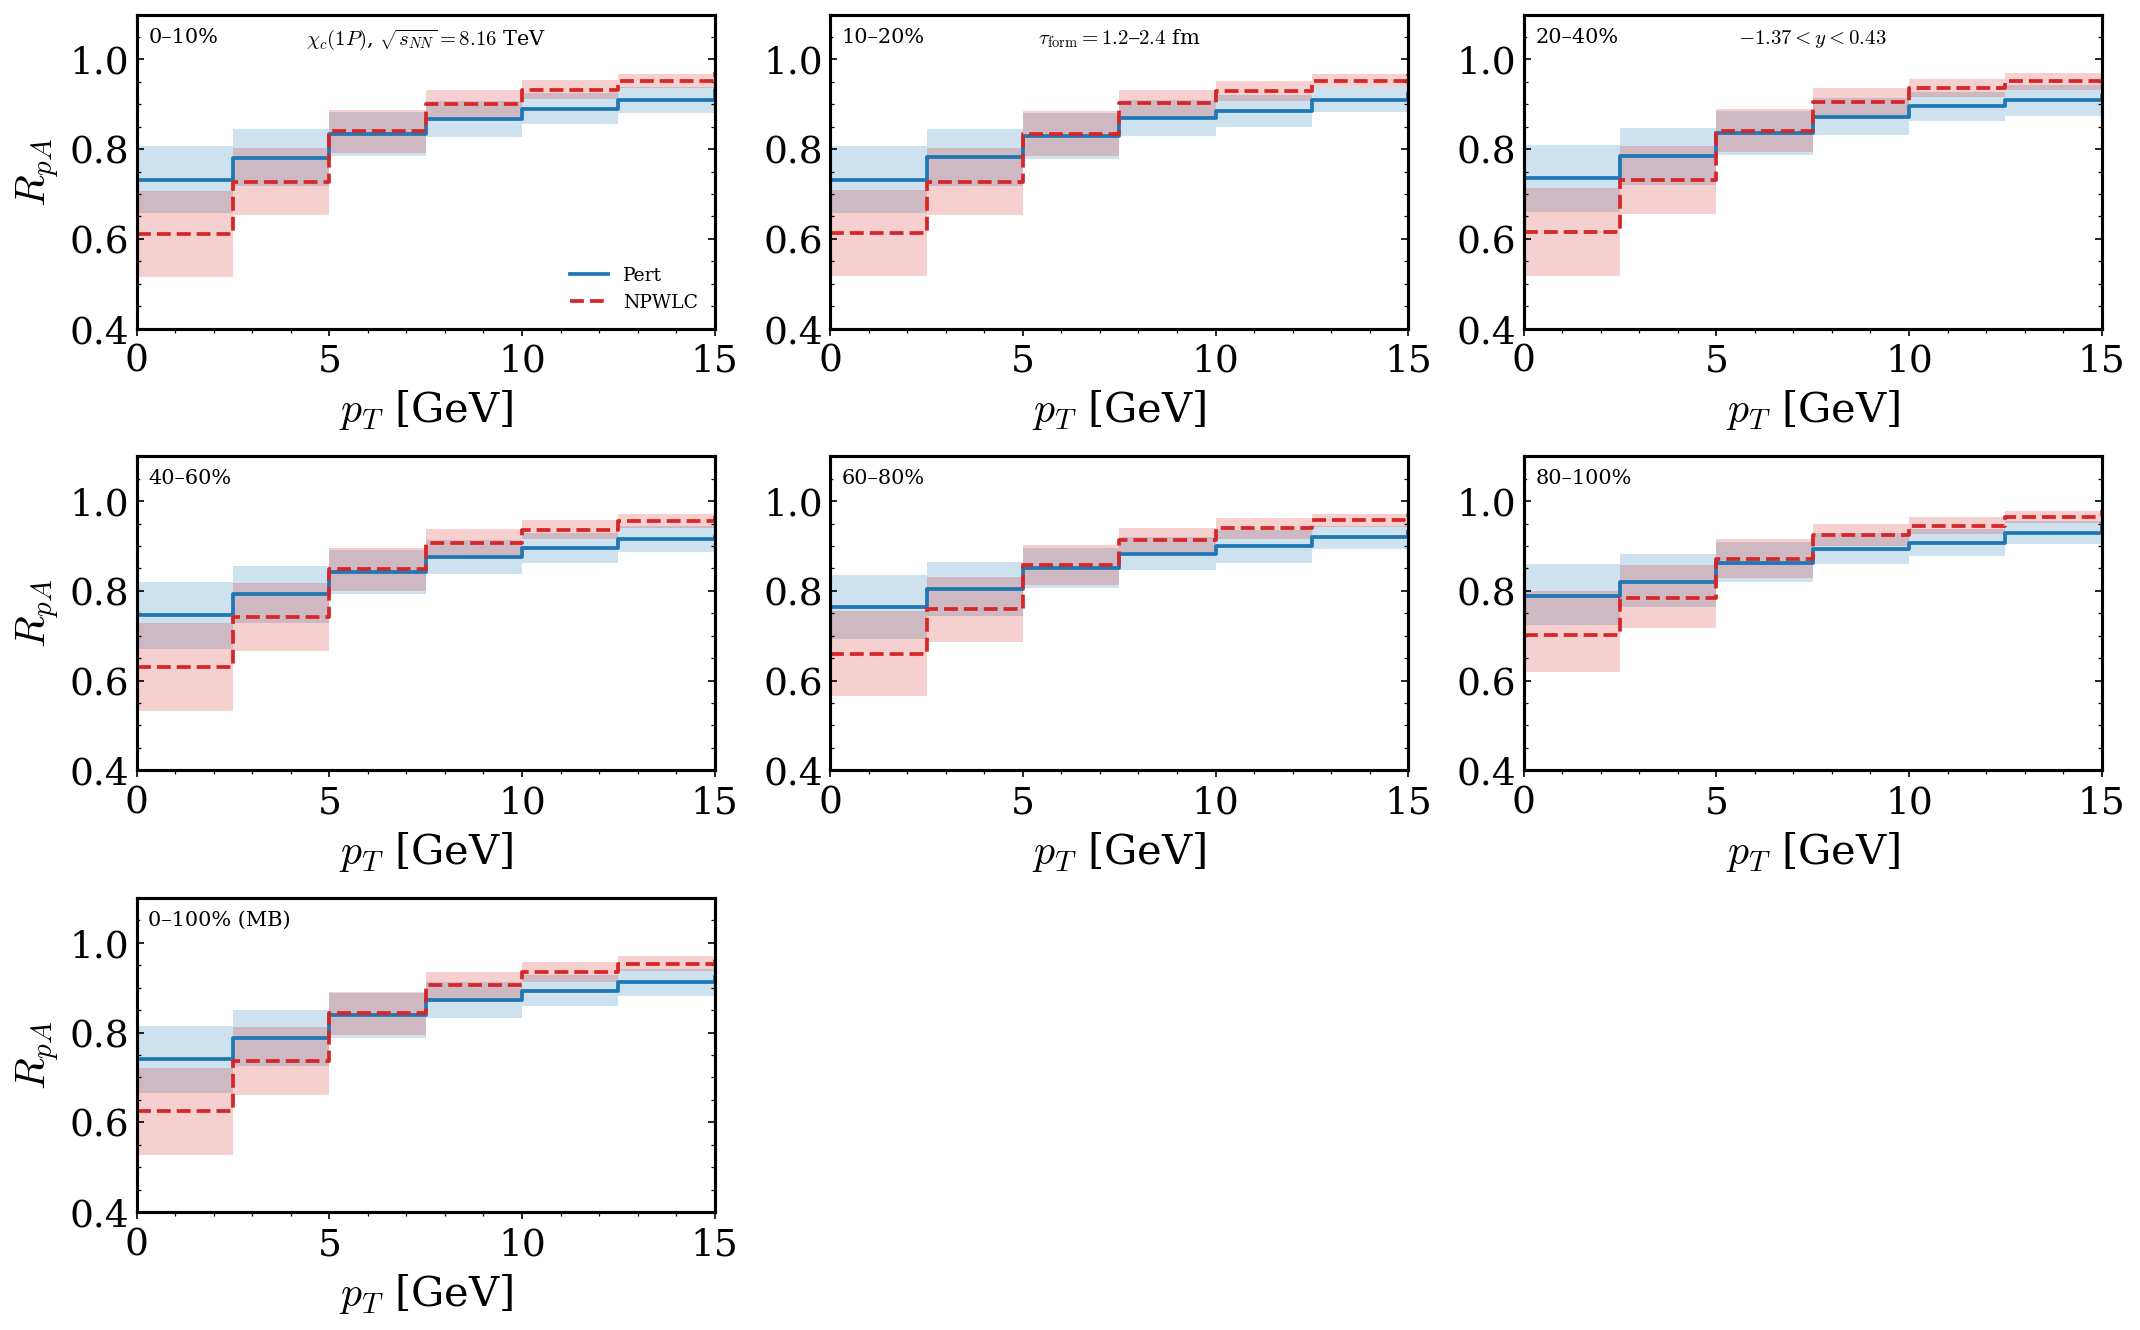

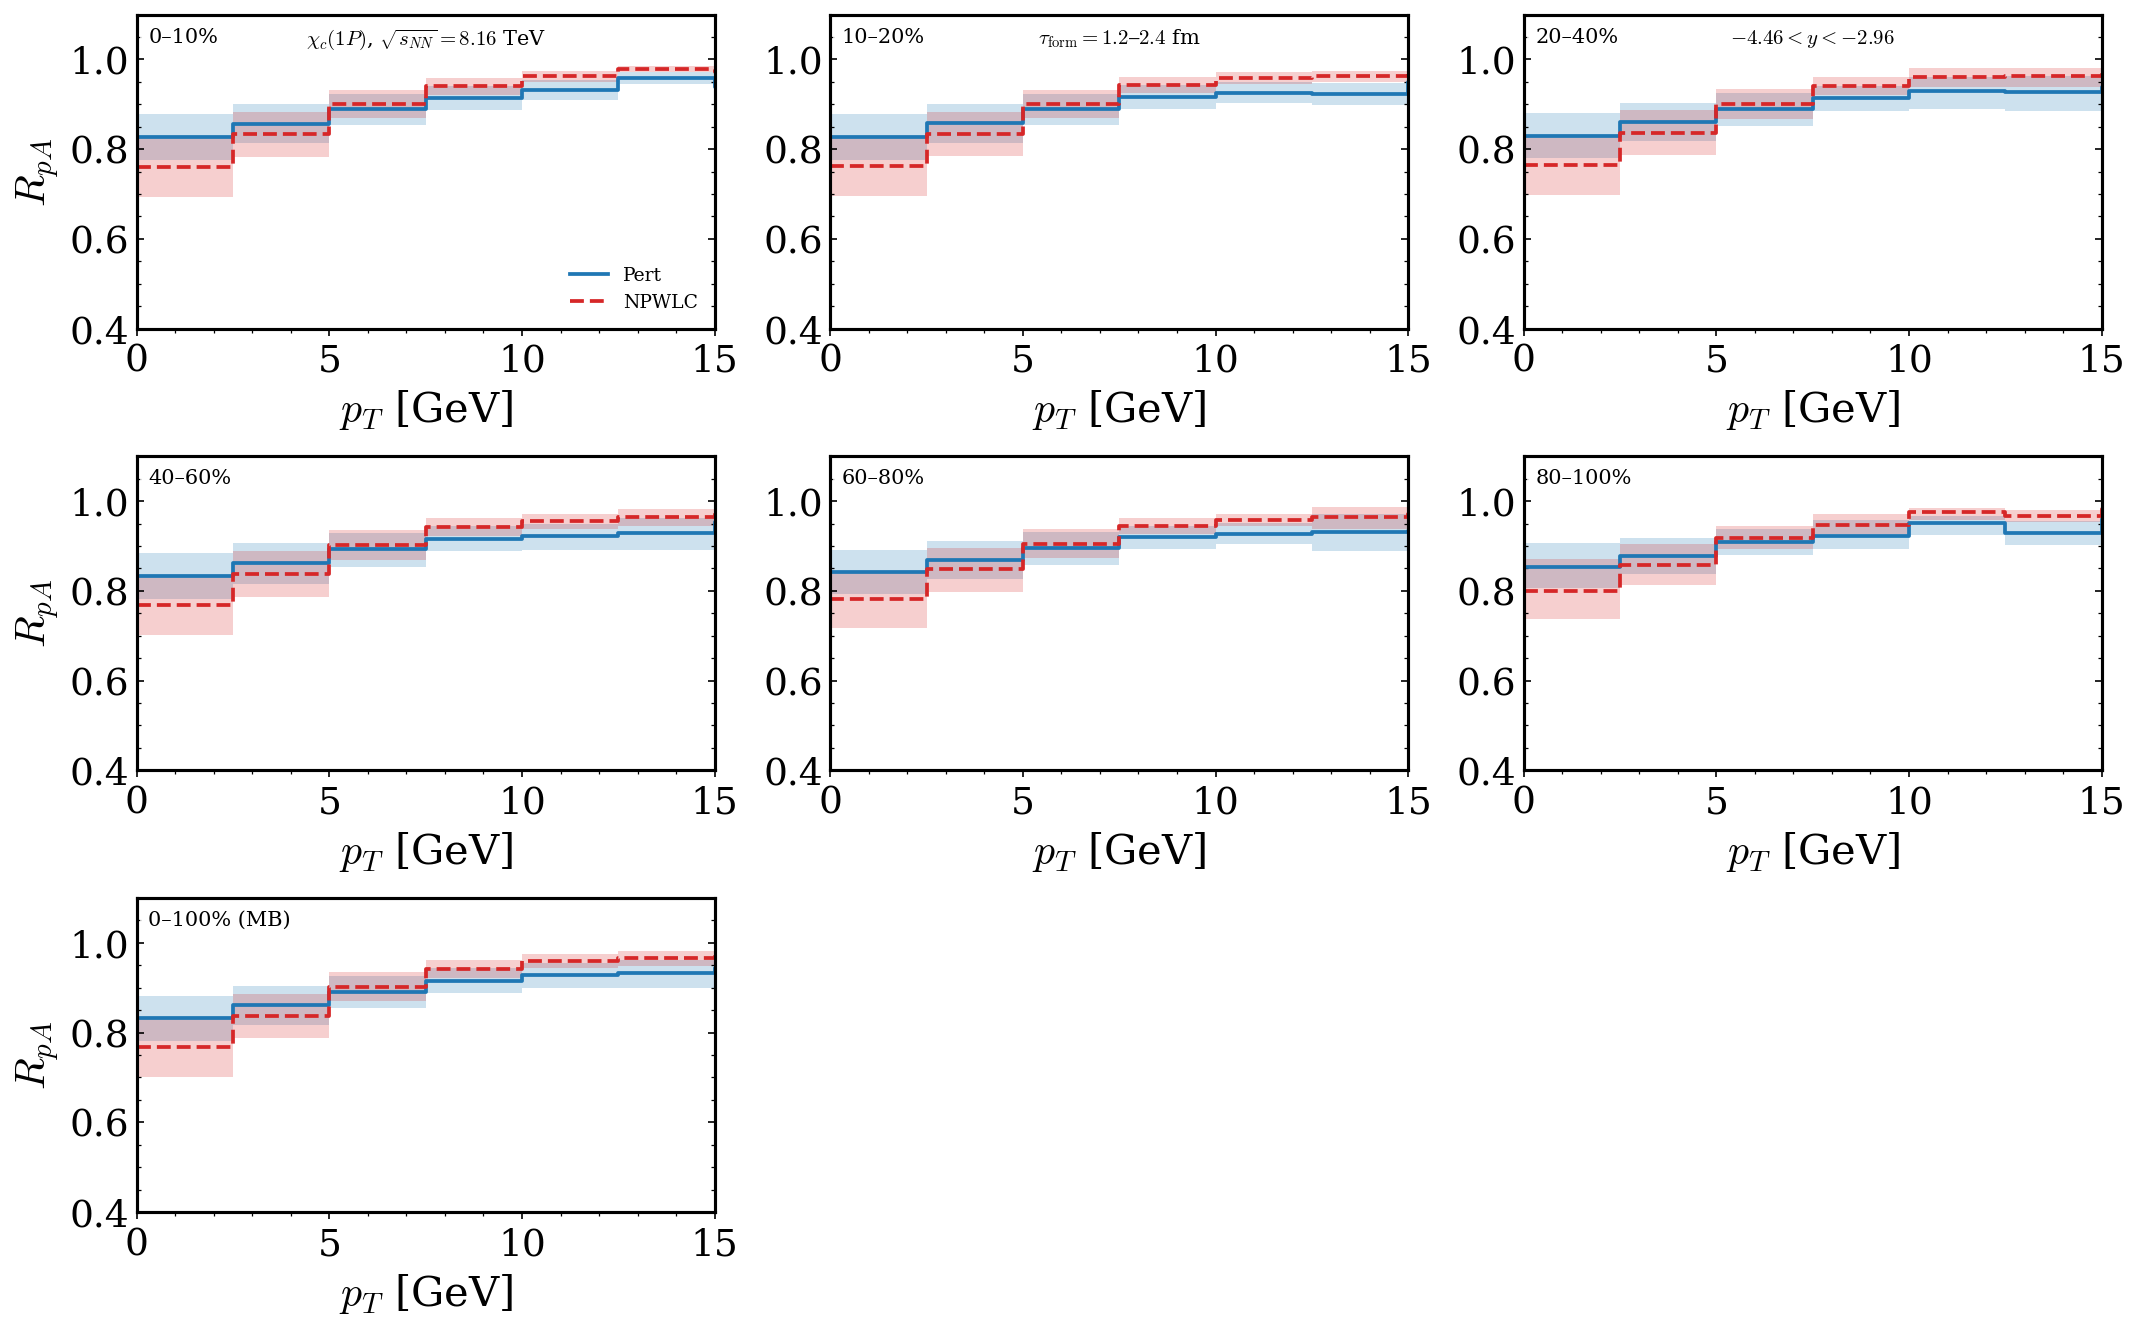

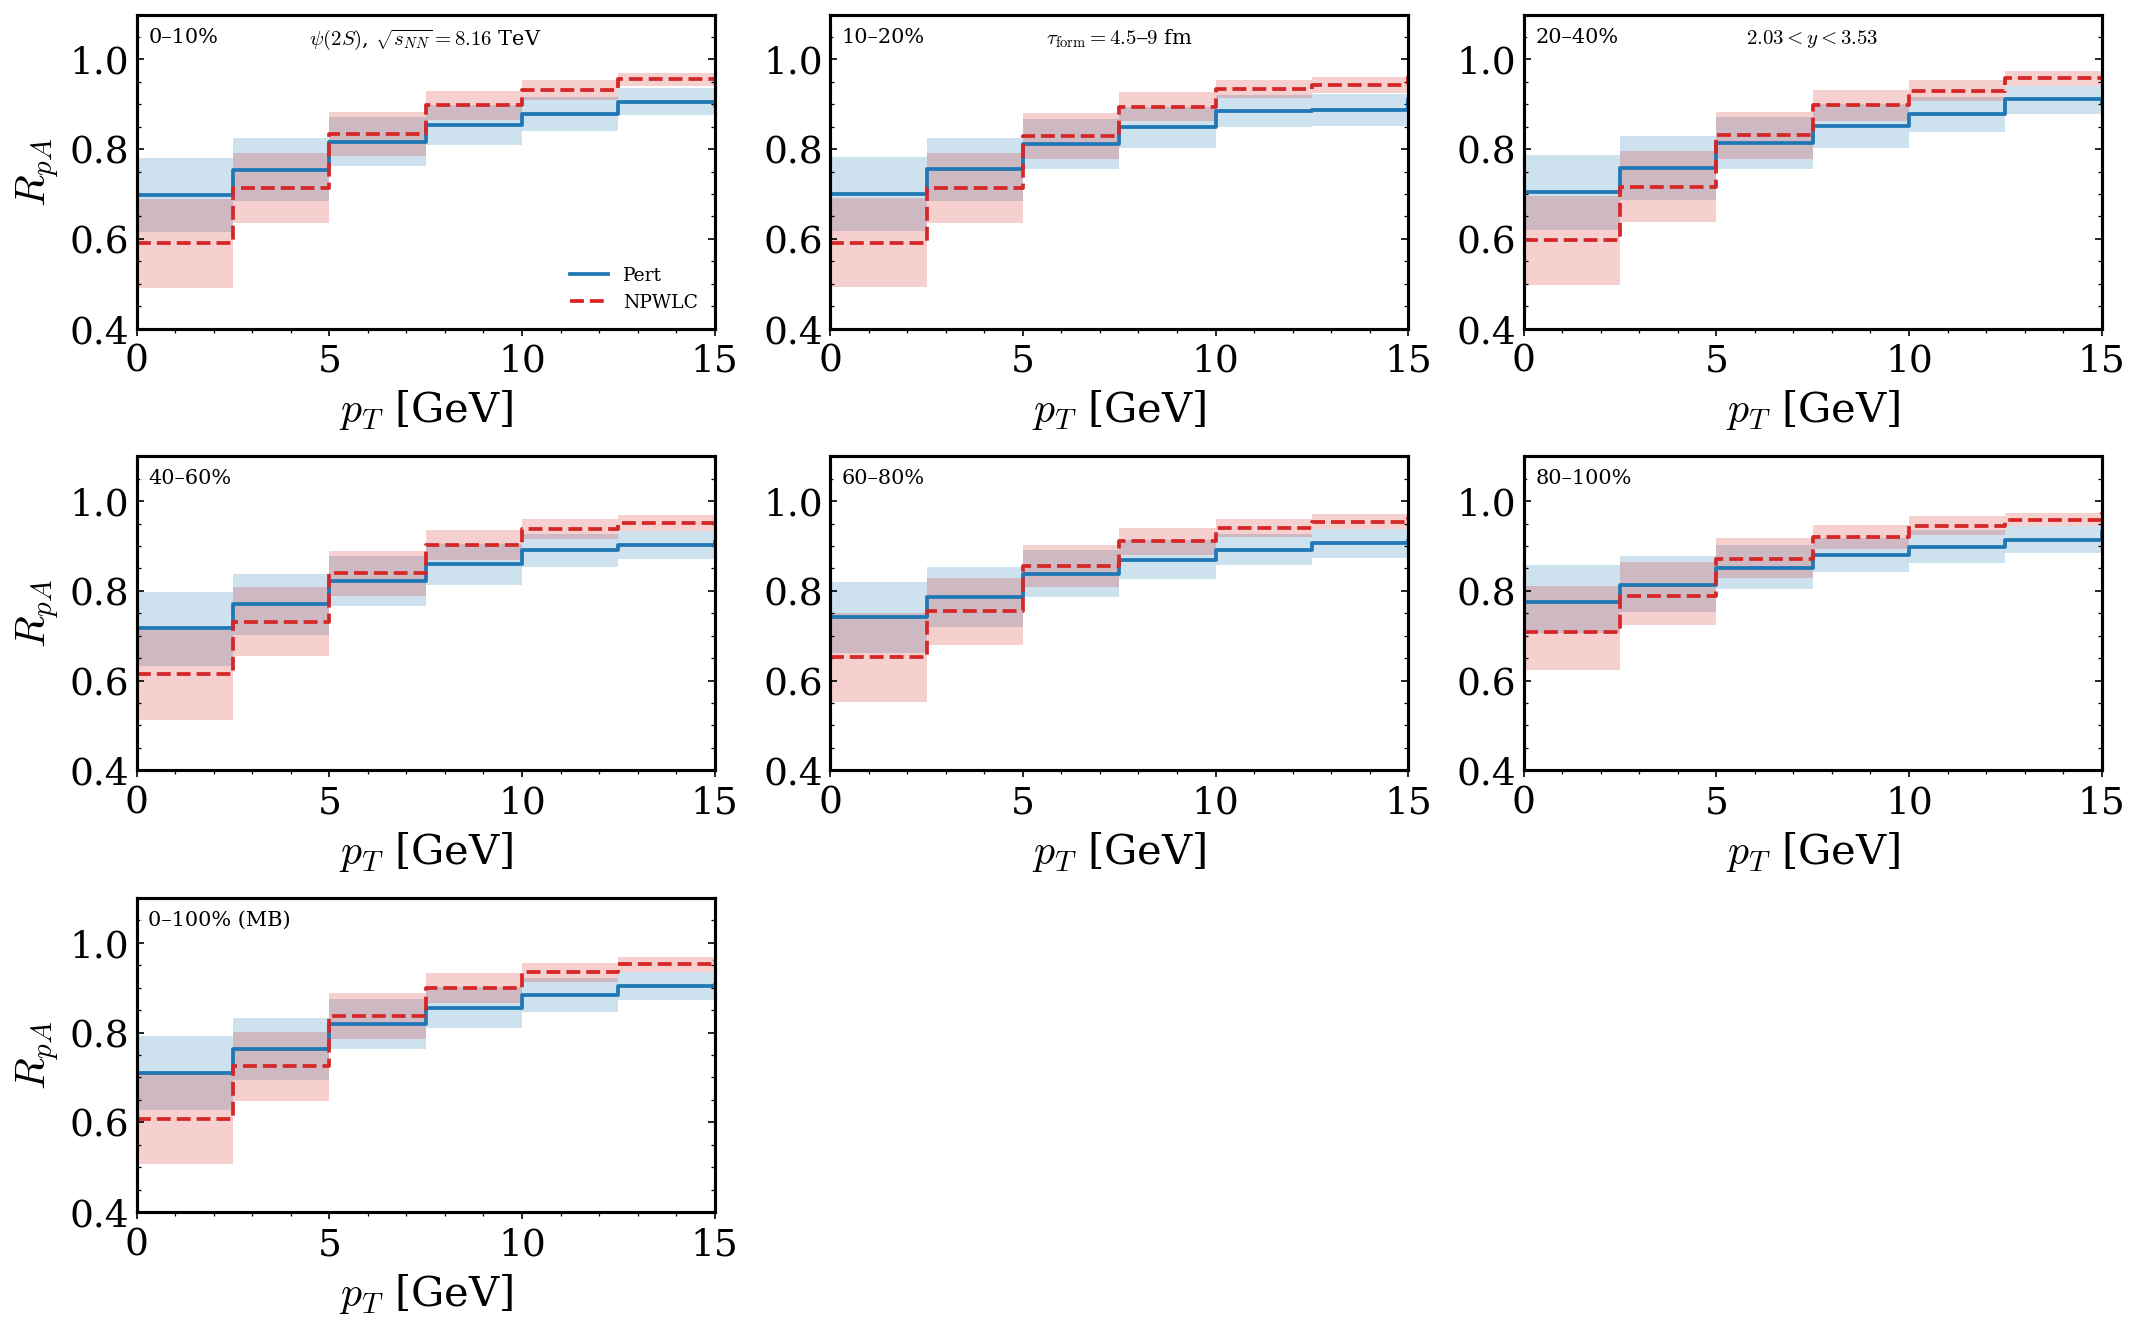

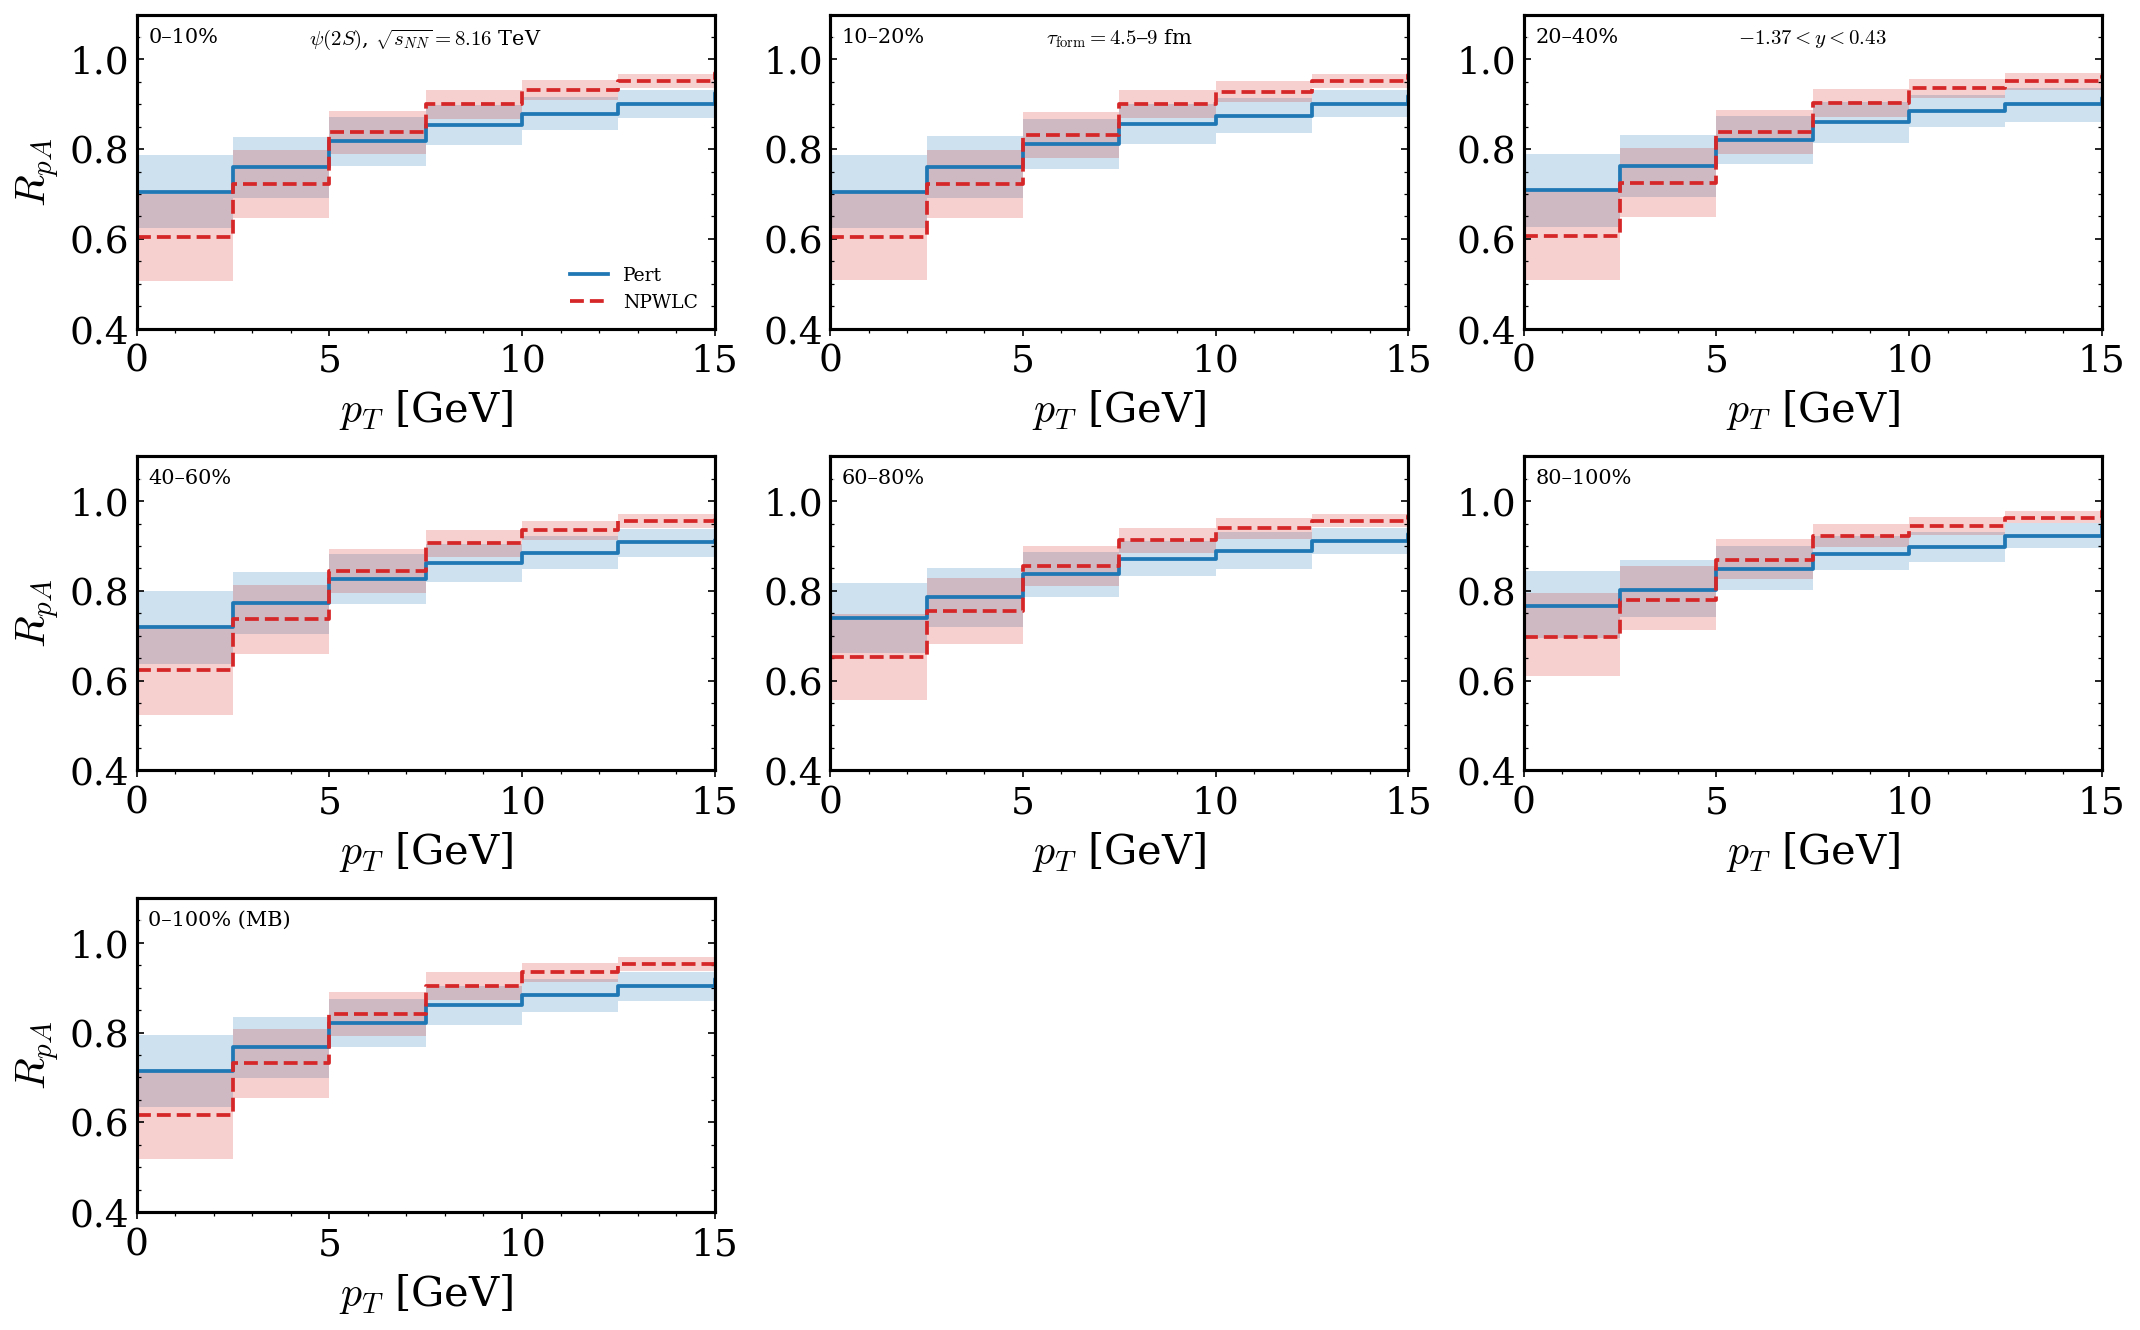

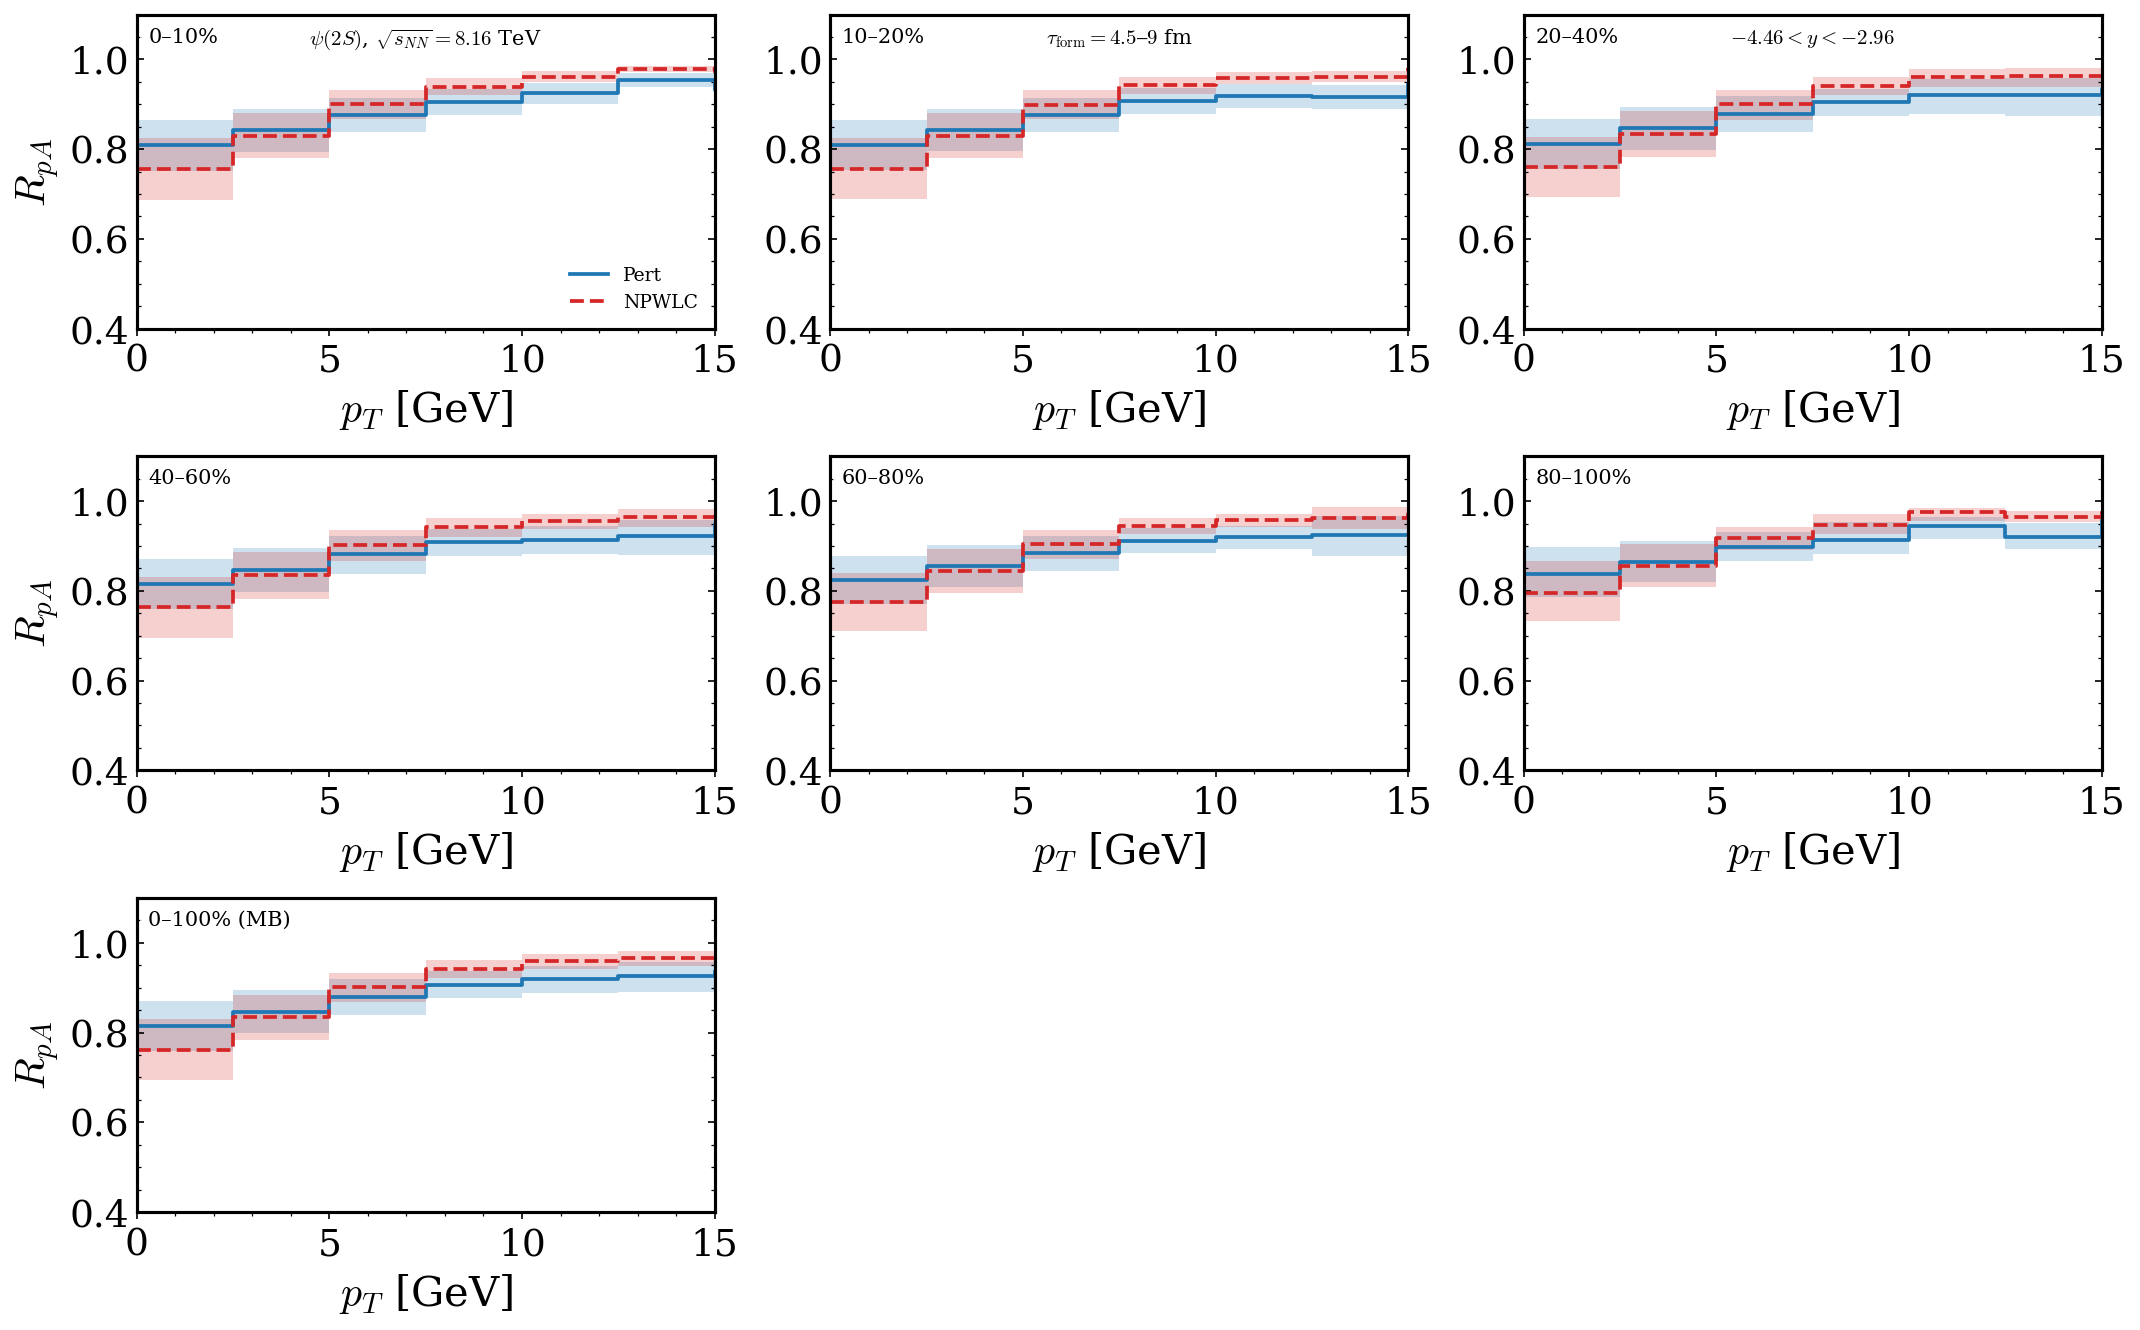

In [ ]:
# --------- Plot: R_pA vs pT (all centralities + MB, per y-window) ---------
for state in PLOT_STATES:
    for yname, y0, y1 in _iter_ywins(Y_WINDOWS):
        if yname not in prim_pt:
            continue
        models_block = prim_pt[yname]
        if not models_block:
            continue

        cent_tags = _sorted_cent_tags(next(iter(models_block.values())))
        n_cent = len(cent_tags)
        n_cols = 3
        n_rows = int(np.ceil(n_cent / n_cols))

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(4.8*n_cols, 3.0*n_rows),
            dpi=DPI, sharex=False, sharey=False
        )
        axes = np.atleast_1d(axes).ravel()

        for ip, cent_tag in enumerate(cent_tags):
            ax = axes[ip]
            for model in MODELS:
                if model not in models_block:
                    continue
                if cent_tag not in models_block[model]:
                    continue
                if state not in models_block[model][cent_tag]:
                    continue

                Rc, Rlo, Rhi, pT_cent = models_block[model][cent_tag][state]
                x_edges, y_c  = step_from_centers(pT_cent, Rc)
                _,       y_lo = step_from_centers(pT_cent, Rlo)
                _,       y_hi = step_from_centers(pT_cent, Rhi)

                col = MODEL_COLORS[model]
                ls  = MODEL_LS[model]
                lab = model if ip == 0 else None

                ax.step(x_edges, y_c, where="post", color=col, ls=ls, lw=1.8, label=lab)
                ax.fill_between(
                    x_edges, y_lo, y_hi,
                    step="post", color=col, alpha=ALPHA_BAND, linewidth=0.0
                )

            # ax.axhline(1.0, color="k", ls=":", lw=0.8)
            ax.set_xlim(PT_WINDOW[0], PT_WINDOW[1])
            # ax.set_ylim(*YLIMS_PT.get(yname, (0.3, 1.1)))
            ax.set_ylim(0.4, 1.1)
            ax.set_xlabel(r"$p_T$ [GeV]")
            if ip % n_cols == 0:
                ax.set_ylabel(r"$R_{pA}$")
            ax.grid(False) # Keeps grid lines OFF inside the plot

            # --- MINIMAL CHANGE FIX: TICKS ONLY ---
            ax.minorticks_on()
            # Ensure major ticks show on the right axis
            ax.tick_params(axis='y', which='major', direction='in', right=True) 
            # Ensure minor ticks show on the right axis
            ax.tick_params(axis='y', which='minor', direction='in', right=True)
            # --------------------------------------

            ax.text(
                0.02, 0.96, cent_tag,
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=10,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
            )

        for k in range(n_cent, len(axes)):
            axes[k].set_visible(False)

        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            axes[0].legend(handles, labels, loc="lower right", fontsize=9, frameon=False)

        # Note placement logic
        tau_lo, tau_hi = TAUFORM[state]
        
        # Line 1: State and Sqrt(s_NN)
        note_line1 = rf"{STATE_LABELS[state]}, $\sqrt{{s_{{NN}}}}={float(ENERGY):.2f}$ TeV"
        axes[0].text(
            0.50, 0.96, note_line1,
            transform=axes[0].transAxes,
            ha="center", va="top",
            fontsize=10
        )
        
        # Line 2: Tau form
        note_line2 = rf"$\tau_{{\rm form}}={tau_lo:.2g}\text{{–}}{tau_hi:.2g}$ fm"
        axes[1].text(
            0.50, 0.96, note_line2,
            transform=axes[1].transAxes,
            ha="center", va="top",
            fontsize=10
        )

        # Line 3: y range form
        note_line3 = rf"${y0:.2f} < y < {y1:.2f}$"
        axes[2].text(
            0.50, 0.96, note_line3,
            transform=axes[2].transAxes,
            ha="center", va="top",
            fontsize=10
        )

        fig.tight_layout()
        if SAVE_PDF:
            safe = yname.replace(" ", "_")
            fig.savefig(
                outdir / f"primordial_RpA_vs_pT_{state}_{safe}_{ENERGY.replace('.','p')}TeV.pdf",
                bbox_inches="tight",
            )

        if SAVE_CSV:
            rows = []
            for model in MODELS:
                if model not in models_block:
                    continue
                for cent_tag in models_block[model]:
                    if state not in models_block[model][cent_tag]:
                        continue
                    Rc, Rlo, Rhi, pT_cent = models_block[model][cent_tag][state]
                    for pv, rc, rlo, rhi in zip(pT_cent, Rc, Rlo, Rhi):
                        rows.append({
                            "energy": ENERGY,
                            "y_window": yname,
                            "model": model,
                            "centrality": cent_tag,
                            "state": state,
                            "pT": pv,
                            "R": rc,
                            "R_lo": rlo,
                            "R_hi": rhi,
                        })
            if rows:
                df_out = pd.DataFrame(rows)
                df_out.to_csv(
                    outdir / f"primordial_RpA_vs_pT_{state}_{yname}_{ENERGY.replace('.','p')}TeV.csv",
                    index=False,
                )

## $R_{pA}$ vs Centrality

In [ ]:
# ======================================================================
#  R_pA vs centrality (with MB horizontal band)
# ======================================================================

prim_cent = {}  # prim_cent[yname][model][state] = (cent_mid,Rc,Rlo,Rhi,Rc_MB,Rlo_MB,Rhi_MB)

def primordial_vs_cent_from_vs_y(
    prim_y_dict,
    y_wins=Y_WINDOWS,
    states=STATES,
):
    """
    Build R_pA vs centrality by averaging R_pA(y) over the chosen y-window
    for each centrality slice + MB.
    """
    out = {}
    for yname, y0, y1 in _iter_ywins(y_wins):
        out[yname] = {}
        for model in MODELS:
            if model not in prim_y_dict:
                continue

            cent_tags = [c for c in prim_y_dict[model].keys() if "MB" not in c]
            mb_tag = [c for c in prim_y_dict[model].keys() if "MB" in c]
            mb_tag = mb_tag[0] if mb_tag else None

            def _cent_key(tag):
                lo, hi = tag.split("–")
                return float(lo)
            cent_tags = sorted(cent_tags, key=_cent_key)

            for s in states:
                cent_mid = []
                Rc_all   = []
                Rlo_all  = []
                Rhi_all  = []

                for ct in cent_tags:
                    if s not in prim_y_dict[model][ct]:
                        continue
                    Rc, Rlo, Rhi, y_cent = prim_y_dict[model][ct][s]
                    mask = (y_cent >= y0) & (y_cent <= y1)
                    if not np.any(mask):
                        continue
                    lo_str, hi_str = ct.split("–")
                    lo = float(lo_str)
                    hi = float(hi_str.strip("%"))
                    cent_mid.append(0.5*(lo+hi))

                    Rc_all.append(float(np.mean(Rc[mask])))
                    Rlo_all.append(float(np.min(Rlo[mask])))
                    Rhi_all.append(float(np.max(Rhi[mask])))

                if not cent_mid:
                    continue

                cent_mid = np.array(cent_mid, float)
                Rc_arr   = np.array(Rc_all,   float)
                Rlo_arr  = np.array(Rlo_all,  float)
                Rhi_arr  = np.array(Rhi_all,  float)

                Rc_MB = Rlo_MB = Rhi_MB = np.nan
                if mb_tag and s in prim_y_dict[model][mb_tag]:
                    Rc_mb, Rlo_mb, Rhi_mb, y_mb = prim_y_dict[model][mb_tag][s]
                    mask_mb = (y_mb >= y0) & (y_mb <= y1)
                    if np.any(mask_mb):
                        Rc_MB  = float(np.mean(Rc_mb[mask_mb]))
                        Rlo_MB = float(np.min(Rlo_mb[mask_mb]))
                        Rhi_MB = float(np.max(Rhi_mb[mask_mb]))

                out[yname].setdefault(model, {})[s] = (
                    cent_mid, Rc_arr, Rlo_arr, Rhi_arr, Rc_MB, Rlo_MB, Rhi_MB
                )

    return out

prim_cent = primordial_vs_cent_from_vs_y(prim_y)

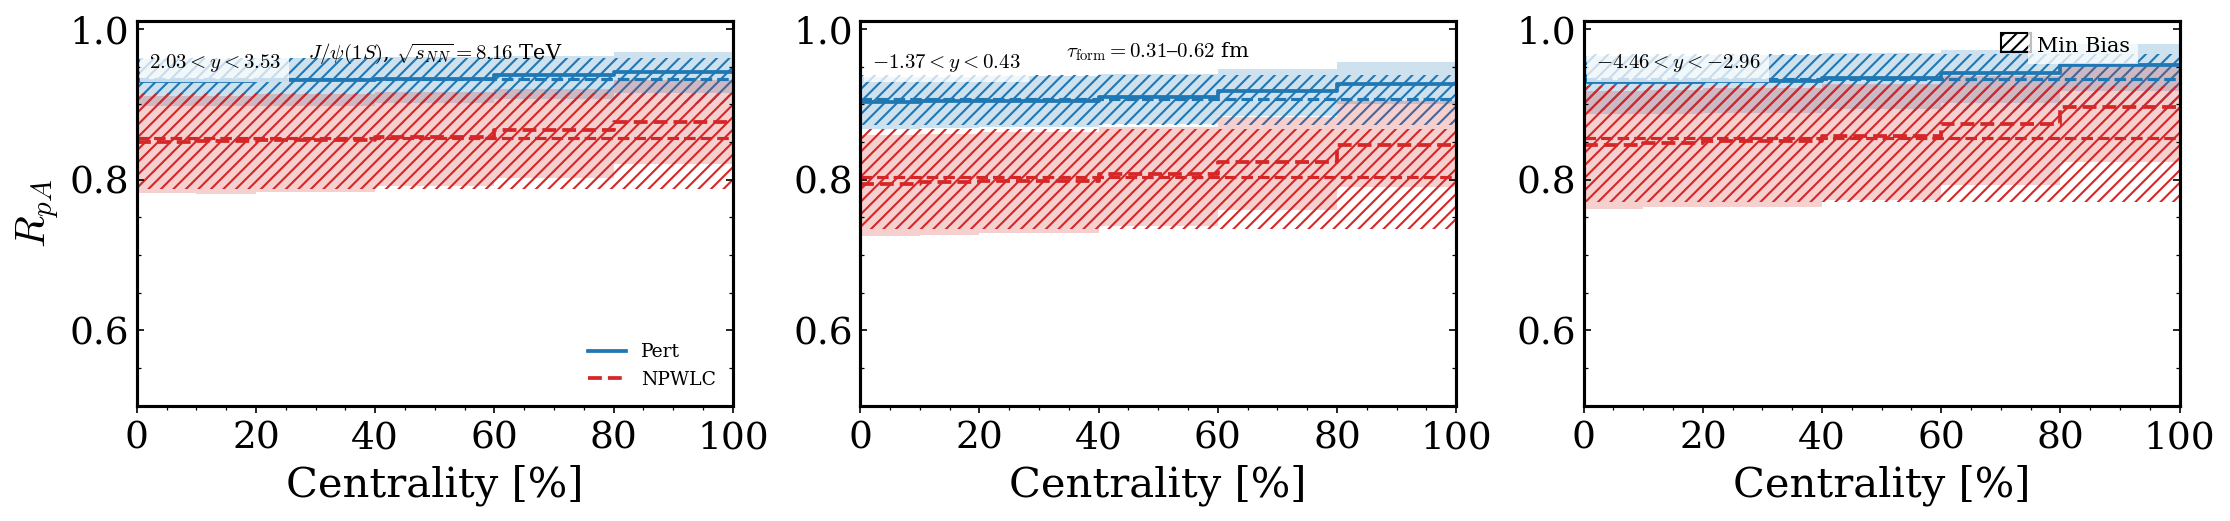

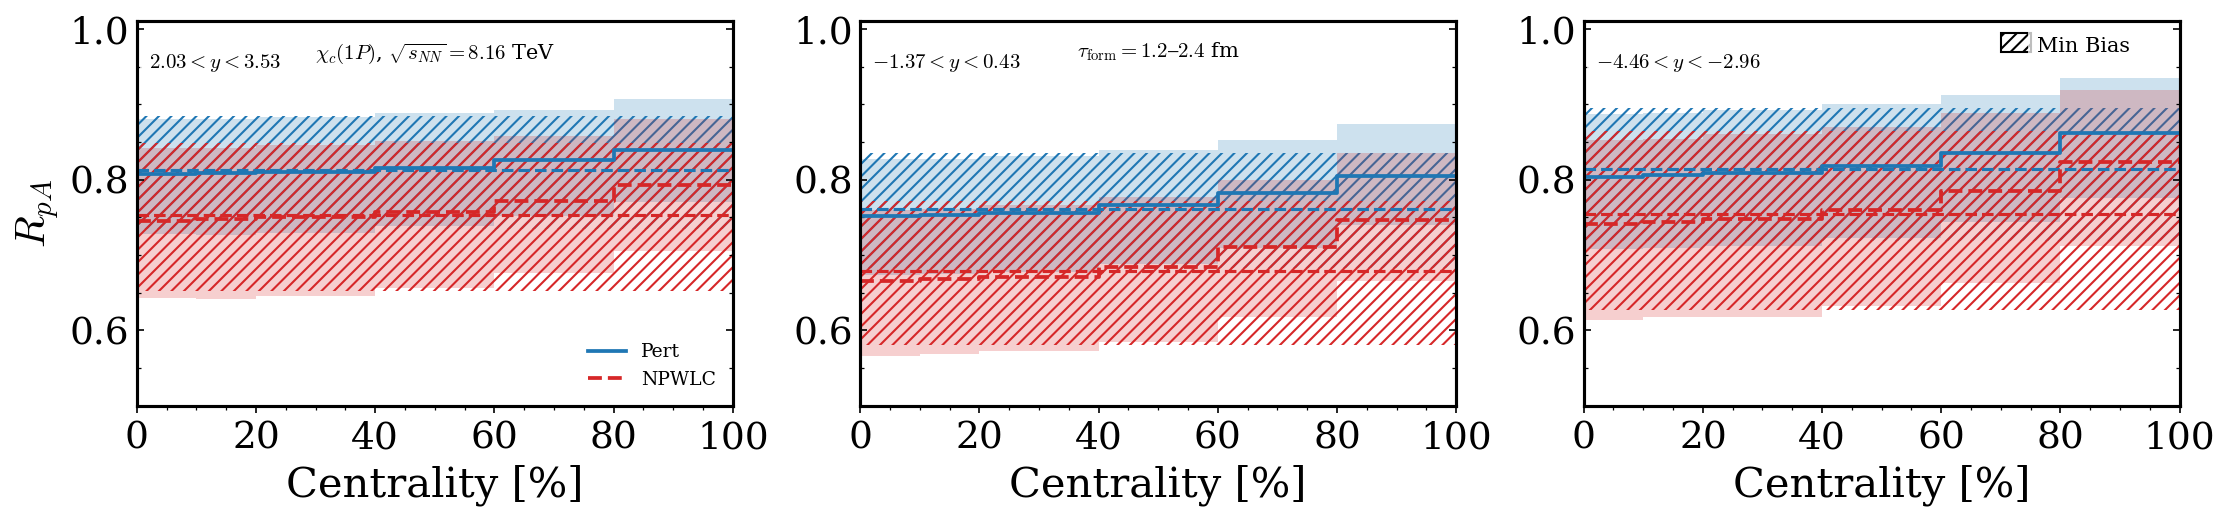

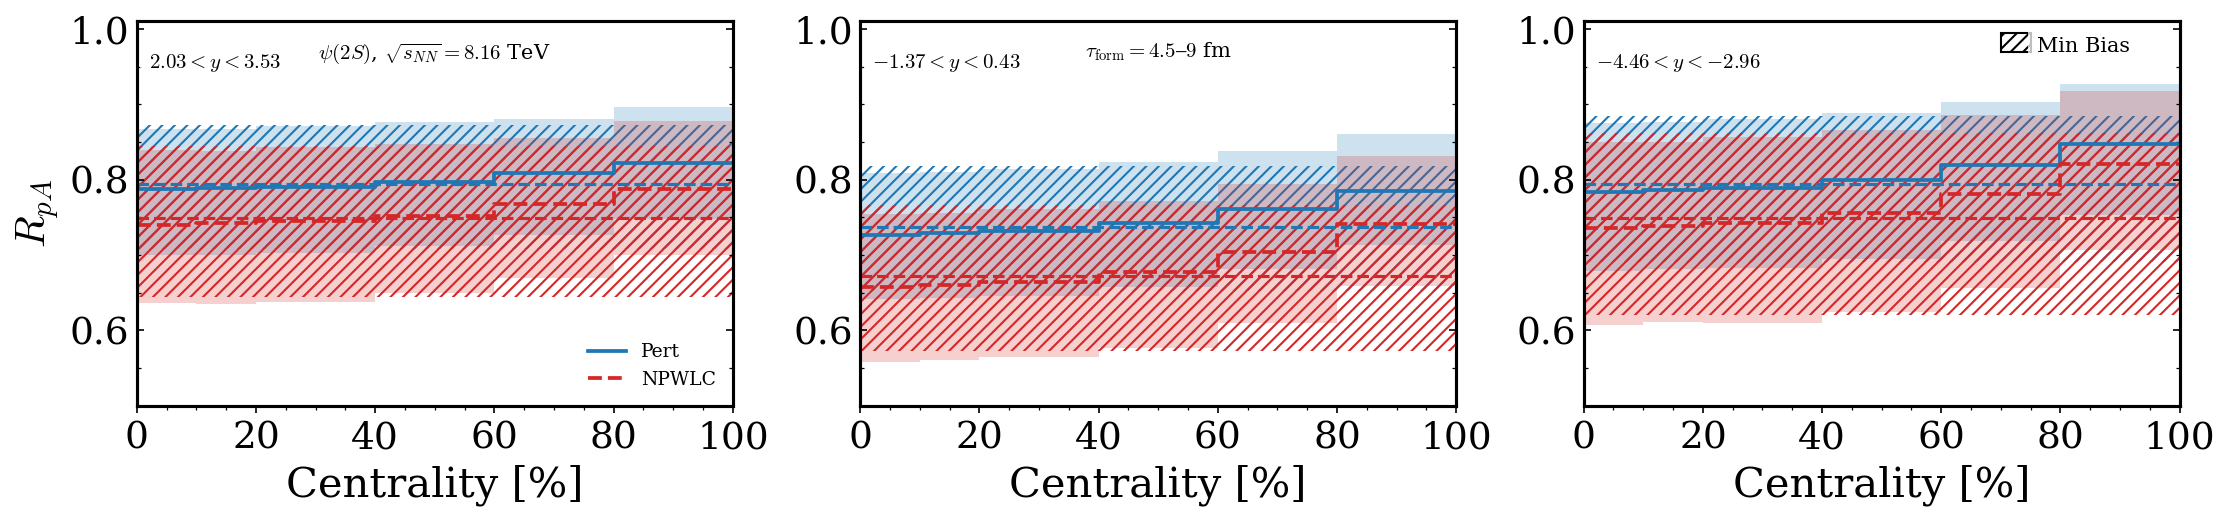

In [ ]:
# --------- Plot: R_pA vs centrality (with MB band) ---------
for state in PLOT_STATES:
    ywins_list = list(_iter_ywins(Y_WINDOWS))
    n_pan = len(ywins_list)

    fig, axes = plt.subplots(1, n_pan, figsize=(5.0*n_pan, 3.6), dpi=DPI, sharey=False)
    axes = np.atleast_1d(axes)

    # Initialize MB data structure outside the loop for later use
    mb_data = {} 

    for iax, (yname, y0, y1) in enumerate(ywins_list):
        ax = axes[iax]
        if yname not in prim_cent:
            ax.set_visible(False)
            continue

        # Temporarily store MB data for this panel
        current_mb_data = None
        
        for model in MODELS:
            if model not in prim_cent[yname]:
                continue
            if state not in prim_cent[yname][model]:
                continue

            cent_mid, Rc, Rlo, Rhi, Rc_MB, Rlo_MB, Rhi_MB = prim_cent[yname][model][state]

            # Store MB data from the first model encountered in this panel
            if model == MODELS[0]:
                current_mb_data = (Rc_MB, Rlo_MB, Rhi_MB)
                
            # Use explicit bin edges like CNM notebook (0-20,20-40,...)
            edges = np.array([CENT_CLASSES[0][0]] + [hi for (_, hi) in CENT_CLASSES], float)

            # assume Rc etc correspond to CENT_CLASSES in order
            y_c  = np.concatenate([Rc,  Rc[-1:]])
            y_lo = np.concatenate([Rlo, Rlo[-1:]])
            y_hi = np.concatenate([Rhi, Rhi[-1:]])

            col = MODEL_COLORS[model]
            ls  = MODEL_LS[model]
            lab = model if iax == 0 else None

            ax.step(edges, y_c, where="post", color=col, ls=ls, lw=1.8, label=lab)
            ax.fill_between(
                edges, y_lo, y_hi,
                step="post", color=col, alpha=ALPHA_BAND, linewidth=0.0
            )

            # Min-bias: horizontal band (hatched) + central line
            if np.isfinite(Rc_MB):
                x_mb = np.array([0.0, 100.0])
                y_mb_lo = np.array([Rlo_MB, Rlo_MB])
                y_mb_hi = np.array([Rhi_MB, Rhi_MB])

                # LAB_MB REMOVED: This removes Min Bias from the legend handles.
                # The color is kept as 'col' as requested to match the model color in the plot.
                ax.fill_between(
                    x_mb, y_mb_lo, y_mb_hi,
                    color="none",
                    hatch="////",
                    edgecolor=col, # KEPT MODEL COLOR
                    linewidth=0.0,
                    # label=lab_mb, <-- LEGEND ENTRY REMOVED
                )
                ax.hlines(
                    Rc_MB, 0.0, 100.0,
                    colors=col, linestyles="--", linewidth=1.5, # KEPT MODEL COLOR
                )
        
        # Store the Min Bias data for later access in the note
        if current_mb_data:
            mb_data[iax] = current_mb_data

        # --- MINIMAL CHANGE FIX: TICKS ONLY ---
        ax.minorticks_on()
        # Ensure major ticks show on the right axis
        ax.tick_params(axis='y', which='major', direction='in', right=True) 
        # Ensure minor ticks show on the right axis
        ax.tick_params(axis='y', which='minor', direction='in', right=True)
        # --------------------------------------

        # ax.axhline(1.0, color="k", ls=":", lw=0.8)
        ax.set_xlim(0.0, 100.0)
        ax.set_ylim(0.5, 1.01)
        ax.set_xlabel("Centrality [%]")
        if iax == 0:
            ax.set_ylabel(r"$R_{pA}$")
        ax.grid(False)

        label = f"${y0:.2f} < y < {y1:.2f}$"
        ax.text(
            0.02, 0.92, label,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
        )

    # LEGEND NOW ONLY CONTAINS MODEL NAMES
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(handles, labels, loc="lower right", frameon=False, fontsize=9)

    # Note placement logic
    tau_lo, tau_hi = TAUFORM[state]

    # 1. State and Sqrt(s_NN) in axes[0] top-center
    note_line1 = rf"{STATE_LABELS[state]}, $\sqrt{{s_{{NN}}}}={float(ENERGY):.2f}$ TeV"
    axes[0].text(
        0.50, 0.95, note_line1,
        transform=axes[0].transAxes,
        ha="center", va="top",
        fontsize=10
    )
    
    # 2. Tau form in axes[1] top-center
    if n_pan > 1 and axes[1].get_visible():
        ax_tau = axes[1]
    else:
        ax_tau = axes[0]
        
    note_line2 = rf"$\tau_{{\rm form}}={tau_lo:.2g}\text{{–}}{tau_hi:.2g}$ fm"
    
    y_pos = 0.95 if ax_tau is axes[1] else 0.85 
    
    ax_tau.text(
        0.50, y_pos, note_line2,
        transform=ax_tau.transAxes,
        ha="center", va="top",
        fontsize=10
    )

    # 3. ADD Min Bias note to the top-right of the THIRD subfigure (axes[2])
# 3. ADD Min Bias note to the top-right of the THIRD subfigure (axes[2])
    if n_pan > 2 and axes[2].get_visible():
        ax_mb = axes[2]
        
        # 1. Draw the small hatched black box (Rectangle patch)
        # Position the patch at the top right, just to the left of where the text starts.
        # Coordinates are relative to the axes (0 to 1).
        
        # Calculate x_start for the text (e.g., 0.98 - width_of_box - gap_to_text)
        patch_x = 0.70 # Start position for the patch (normalized axis units)
        patch_y = 0.92 # Y position (just below the top edge)
        
        # Define the patch properties
        patch = plt.Rectangle(
            (patch_x, patch_y), # (x, y) start position
            0.05, 0.05,        # width, height
            transform=ax_mb.transAxes,
            facecolor='none',
            edgecolor='k',     # Black color for the lines
            hatch='////',      # Hashing pattern to match the plot
            linewidth=1.0,
            clip_on=False # Ensure it draws even at the very edge
        )
        ax_mb.add_patch(patch)
        
        # 2. Draw the text next to the patch
        note_mb = "Min Bias"
        ax_mb.text(
            patch_x + 0.05 + 0.01, 0.96, note_mb, # Position text to the right of the patch
            transform=ax_mb.transAxes,
            ha="left", va="top", # Use ha="left" now that we placed the patch
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
        )

    fig.tight_layout()
    if SAVE_PDF:
        fig.savefig(
            outdir / f"primordial_RpA_vs_cent_{state}_{ENERGY.replace('.','p')}TeV.pdf",
            bbox_inches="tight"
        )